## 0. Package loading and installation



In [1]:
# Commented out IPython magic to ensure Python compatibility.
# For Jupyter/Colab notebooks
%reset -f
import gc
gc.collect()

import numpy as np
import pandas as pd
import time

#conda install -c conda-forge \
#    numpy \
#    scipy \
#    pandas \
#    pyarrow \
#    scikit-survival \
#    spyder \
#    lifelines

# conda install -c conda-forge fastparquet
# conda install -c conda-forge xgboost
# conda install -c conda-forge pytorch cpuonly
# conda install -c pytorch pytorch cpuonly
# conda install -c conda-forge matplotlib
# conda install -c conda-forge seaborn
# conda install spyder-notebook -c spyder-ide
# conda install notebook nbformat nbconvert
# conda install -c conda-forge xlsxwriter
# conda install -c conda-forge shap

# import subprocess, sys

# subprocess.check_call([
#     sys.executable,
#     "-m",
#     "pip",
#     "install",
#     "matplotlib"
# ])

# subprocess.check_call([
#     sys.executable,
#     "-m",
#     "pip",
#     "install",
#     "seaborn"
# ])

print("numpy:", np.__version__)


from sksurv.metrics import (
    concordance_index_ipcw,
    brier_score,
    integrated_brier_score
)
from sksurv.util import Surv

#Dput
def dput_df(df, digits=6):
    data = {
        "columns": list(df.columns),
        "data": [
            [round(x, digits) if isinstance(x, (float, np.floating)) else x
             for x in row]
            for row in df.to_numpy()
        ]
    }
    print(data)


#Glimpse function
def glimpse(df, max_width=80):
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    for col in df.columns:
        dtype = df[col].dtype
        preview = df[col].astype(str).head(5).tolist()
        preview_str = ", ".join(preview)
        if len(preview_str) > max_width:
            preview_str = preview_str[:max_width] + "..."
        print(f"{col:<30} {str(dtype):<15} {preview_str}")
#Tabyl function
def tabyl(series):
    counts = series.value_counts(dropna=False)
    props = series.value_counts(normalize=True, dropna=False)
    return pd.DataFrame({"value": counts.index,
                         "n": counts.values,
                         "percent": props.values})
#clean_names
import re

def clean_names(df):
    """
    Mimic janitor::clean_names for pandas DataFrames.
    - Lowercase
    - Replace spaces and special chars with underscores
    - Remove non-alphanumeric/underscore
    """
    new_cols = []
    for col in df.columns:
        # lowercase
        col = col.lower()
        # replace spaces and special chars with underscore
        col = re.sub(r"[^\w]+", "_", col)
        # strip leading/trailing underscores
        col = col.strip("_")
        new_cols.append(col)
    df.columns = new_cols
    return df

numpy: 2.0.1


## Load data

In [2]:

from pathlib import Path

BASE_DIR = Path(
    r"G:\My Drive\Alvacast\SISTRAT 2023\data\20241015_out\pred1"
)

import pickle

with open(BASE_DIR / "imputations_list_jan26.pkl", "rb") as f:
    imputations_list_jan26 = pickle.load(f)

imputation_1 = pd.read_parquet(
    BASE_DIR / "imputation_1.parquet",
    engine="fastparquet"
)

In [3]:

import pandas as pd

for i in range(1, 6):
    globals()[f"imputation_nodum_{i}"] = pd.read_parquet(
        BASE_DIR / f"imputation_nondum_{i}.parquet",
        engine="fastparquet"
    )

In [4]:
from IPython.display import display, HTML
import io
import sys

def fold_output(title, func):
    buffer = io.StringIO()
    sys.stdout = buffer
    func()
    sys.stdout = sys.__stdout__
    
    html = f"""
    <details>
      <summary>{title}</summary>
      <pre>{buffer.getvalue()}</pre>
    </details>
    """
    display(HTML(html))


fold_output(
    "Show imputation_nodum_1 structure",
    lambda: imputation_nodum_1.info()
)

fold_output(
    "Show imputation_1 structure",
    lambda: imputation_1.info()
)

In [5]:
from IPython.display import display, Markdown

if isinstance(imputations_list_jan26, list) and len(imputations_list_jan26) > 0:
    display(Markdown(f"**First element type:** `{type(imputations_list_jan26[0])}`"))

    if isinstance(imputations_list_jan26[0], dict):
        display(Markdown(f"**First element keys:** `{list(imputations_list_jan26[0].keys())}`"))

    elif isinstance(imputations_list_jan26[0], (pd.DataFrame, np.ndarray)):
        display(Markdown(f"**First element shape:** `{imputations_list_jan26[0].shape}`"))

**First element type:** `<class 'pandas.core.frame.DataFrame'>`

**First element shape:** `(88504, 56)`

This code block:

1.  **Imports the `pickle` library**: This library implements binary protocols for serializing and de-serializing a Python object structure.
2.  **Specifies the `file_path`**: It points to the `.pkl` file you selected.
3.  **Opens the file in binary read mode (`'rb'`)**: This is necessary for loading pickle files.
4.  **Loads the object**: `pickle.load(f)` reads the serialized object from the file and reconstructs it in memory.
5.  **Prints confirmation and basic information**: It verifies that the file was loaded and shows the type of the loaded object, and some details about the first element if it's a list containing common data structures.

### Format data

Due to inconsistencies and structural heterogeneity across previously merged datasets, we decided not to proceed with a direct inspection and comparison of column names between the first imputed dataset from `imputations_list_jan26` (which likely included dummy-encoded variables) and `imputation_nodum_1` (which likely retained non–dummy-encoded variables).

Instead, we reconstructed the analytic datasets *de novo* using the most recent source files available in the original directory (`BASE_DIR`). Time-to-event variables were re-derived to ensure internal consistency. Variables that could introduce information leakage (e.g., time from admission) were excluded, and the center identifier variable was removed prior to modeling.

In [6]:
#1.2. Build Surv objects from df_final
from IPython.display import display, Markdown
from sksurv.util import Surv

for i in range(1, 6):
    # Get the DataFrame
    df = globals()[f"imputation_nodum_{i}"]

    # Extract time and event arrays
    time_readm  = df["readmit_time_from_disch_m"].to_numpy()
    event_readm = (df["readmit_event"].to_numpy() == 1)
    time_death  = df["death_time_from_disch_m"].to_numpy()
    event_death = (df["death_event"].to_numpy() == 1)

    # Create survival objects
    y_surv_readm = Surv.from_arrays(event=event_readm, time=time_readm)
    y_surv_death = Surv.from_arrays(event=event_death, time=time_death)

    # Store in global variables (optional but matches your pattern)
    globals()[f"y_surv_readm_{i}"]  = y_surv_readm
    globals()[f"y_surv_death_{i}"]  = y_surv_death

    # Print info
    display(Markdown(f"\n--- Imputation {i} ---"))
    display(Markdown(
    f"**y_surv_readm dtype:** {y_surv_readm.dtype}  \n"
    f"**shape:** {y_surv_readm.shape}"
    ))
    display(Markdown(
    f"**y_surv_death dtype:** {y_surv_death.dtype}  \n"
    f"**shape:** {y_surv_death.shape}"
    ))



--- Imputation 1 ---

**y_surv_readm dtype:** [('event', '?'), ('time', '<f8')]  
**shape:** (88504,)

**y_surv_death dtype:** [('event', '?'), ('time', '<f8')]  
**shape:** (88504,)


--- Imputation 2 ---

**y_surv_readm dtype:** [('event', '?'), ('time', '<f8')]  
**shape:** (88504,)

...

**y_surv_readm dtype:** [('event', '?'), ('time', '<f8')]  
**shape:** (88504,)

**y_surv_death dtype:** [('event', '?'), ('time', '<f8')]  
**shape:** (88504,)


--- Imputation 5 ---

**y_surv_readm dtype:** [('event', '?'), ('time', '<f8')]  
**shape:** (88504,)

**y_surv_death dtype:** [('event', '?'), ('time', '<f8')]  
**shape:** (88504,)

In [7]:
fold_output(
    "Show imputation_nodum_1 (newer database) glimpse",
    lambda: glimpse(imputation_nodum_1)
)
fold_output(
    "Show first db of imputations_list_jan26 (older) glimpse",
    lambda: glimpse(imputations_list_jan26[0])
)

For each imputed dataset (1–5), we identified and removed predictors with zero variance, as they provide no useful information and can destabilize models. We printed the dropped variables and produced a cleaned version of each design matrix. This ensures that all downstream analyses use only informative predictors.

In [8]:
# Keep only these objects
objects_to_keep = {
    "objects_to_keep",
    "imputation_nodum_1",
    "imputation_nodum_2",
    "imputation_nodum_3",
    "imputation_nodum_4",
    "imputation_nodum_5",
    "y_surv_readm",
    "y_surv_death",
    "imputations_list_jan26"
}

import types

for name in list(globals().keys()):
    obj = globals()[name]
    if (
        name not in objects_to_keep
        and not name.startswith("_")
        and not callable(obj)
        and not isinstance(obj, types.ModuleType)  # <- protects ALL modules
    ):
        del globals()[name]

In [9]:
from IPython.display import display, Markdown

# 1. Define columns to exclude (same as before)
target_cols = [
    "readmit_time_from_disch_m",
    "readmit_event",
    "death_time_from_disch_m",
    "death_event",
]

leak_time_cols = [
    "readmit_time_from_adm_m",
    "death_time_from_adm_m",
]

center_id = ["center_id"]

cols_to_exclude = target_cols + center_id  + leak_time_cols

# 2. Create list of your EXISTING imputation DataFrames (1-5)
imputed_dfs = [
    imputation_nodum_1,
    imputation_nodum_2,
    imputation_nodum_3,
    imputation_nodum_4,
    imputation_nodum_5
]

# 3. Preprocessing loop
X_reduced_list = []

for d, df in enumerate(imputed_dfs):
    imputation_num = d + 1  # Convert 0-index to 1-index for display

    display(Markdown(f"\n=== Imputation dataset {imputation_num} ==="))

    # a) Identify and drop constant predictors
    const_mask = (df.nunique(dropna=False) <= 1)
    dropped_const = df.columns[const_mask].tolist()
    display(Markdown(f"**Constant predictors dropped ({len(dropped_const)}):**"))
    display(Markdown(f"{dropped_const if dropped_const else 'None'}"))

    # b) Remove constant columns
    X_reduced = df.loc[:, ~const_mask]

    # c) Drop target/leakage columns (if present)
    cols_to_drop = [col for col in cols_to_exclude if col in X_reduced.columns]
    if cols_to_drop:
        X_reduced = X_reduced.drop(columns=cols_to_drop)
        display(Markdown(f"**Dropped target/leakage columns:** {cols_to_drop}"))
    else:
        display(Markdown("No target/leakage columns found to drop"))

    # d) Store cleaned DataFrame
    X_reduced_list.append(X_reduced)

    # e) Report shapes
    display(Markdown(f"**Original shape:** {df.shape}"))
    display(Markdown(
        f"**Cleaned shape:** {X_reduced.shape} "
        f"(removed {df.shape[1] - X_reduced.shape[1]} columns)"
    ))

display(Markdown("\n✅ **Preprocessing complete! X_reduced_list contains 5 cleaned DataFrames.**"))


=== Imputation dataset 1 ===

**Constant predictors dropped (0):**

None

**Dropped target/leakage columns:** ['readmit_time_from_disch_m', 'readmit_event', 'death_time_from_disch_m', 'death_event', 'center_id', 'readmit_time_from_adm_m', 'death_time_from_adm_m']

**Original shape:** (88504, 43)

...

None

**Dropped target/leakage columns:** ['readmit_time_from_disch_m', 'readmit_event', 'death_time_from_disch_m', 'death_event', 'center_id', 'readmit_time_from_adm_m', 'death_time_from_adm_m']

**Original shape:** (88504, 43)

**Cleaned shape:** (88504, 36) (removed 7 columns)


✅ **Preprocessing complete! X_reduced_list contains 5 cleaned DataFrames.**

### Dummify
A structured preprocessing pipeline was implemented prior to modeling. Ordered categorical variables (e.g., housing status, educational attainment, clinical evaluations, and substance use frequency) were manually mapped to numeric scales reflecting their natural ordering. For nominal categorical variables, prespecified reference categories were enforced to ensure consistent baseline comparisons across imputations. All remaining categorical predictors were then converted to dummy variables using one-hot encoding with the first category dropped to prevent multicollinearity. The procedure was applied consistently across all imputed datasets to ensure harmonized model inputs.


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype

def preprocess_features_robust(df):
    df_clean = df.copy()

    # ---------------------------------------------------------
    # 1. Ordinal encoding (your existing code)
    # ---------------------------------------------------------
    ordered_mappings = {
        # --- NEW: Housing & Urbanicity ---
        "tenure_status_household": {
            "illegal settlement": 4,                       # Situación Calle
            "stays temporarily with a relative": 3,        # Allegado
            "others": 2,                                   # En pensión / Otros
            "renting": 1,                                  # Arrendando
            "owner/transferred dwellings/pays dividends": 0 # Vivienda Propia
        },
        "urbanicity_cat": {
            "1.Rural": 2,
            "2.Mixed": 1,
            "3.Urban": 0
        },

        # --- Clinical Evaluations (Minimo -> Intermedio -> Alto) ---
        "evaluacindelprocesoteraputico": {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_consumo":      {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_fam":          {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_relinterp":    {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_ocupacion":    {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_sm":           {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_fisica":       {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_transgnorma":  {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},

        # --- Frequency (Less freq -> More freq) ---
        "prim_sub_freq_rec": {
            "1.≤1 day/wk": 0,
            "2.2–6 days/wk": 1,
            "3.Daily": 2
        },

        # --- Education (Less -> More) ---
        "ed_attainment_corr": {
            "3-Completed primary school or less": 2,
            "2-Completed high school or less": 1,
            "1-More than high school": 0
        }
    }

    for col, mapping in ordered_mappings.items():
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.strip()
            df_clean[col] = df_clean[col].map(mapping)

            n_missing = df_clean[col].isnull().sum()
            if n_missing > 0:
                if n_missing == len(df_clean):
                    print(f"⚠️ WARNING: Mapping failed completely for '{col}'.")
                mode_val = df_clean[col].mode()[0]
                df_clean[col] = df_clean[col].fillna(mode_val)

    # ---------------------------------------------------------
    # 2. FORCE reference categories for dummies
    # ---------------------------------------------------------
    dummy_reference = {
        "sex_rec": "man",
        "plan_type_corr": "ambulatory",
        "marital_status_rec": "married/cohabiting",
        "cohabitation": "alone",
        "sub_dep_icd10_status": "hazardous consumption",
        "tr_outcome": "completion",
        "adm_motive": "spontaneous consultation",
        "tipo_de_vivienda_rec2": "formal housing",
        "plan_type_corr": "pg-pab",
        "occupation_condition_corr24": "employed",
        "any_violence": "0.No domestic violence/sex abuse",
        "first_sub_used": "marijuana",
        "primary_sub_mod": "marijuana",
        }

    for col, ref in dummy_reference.items():
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.strip()
            cats = df_clean[col].unique().tolist()

            if ref in cats:
                new_order = [ref] + [c for c in cats if c != ref]
                cat_type = CategoricalDtype(categories=new_order, ordered=False)
                df_clean[col] = df_clean[col].astype(cat_type)
            else:
                print(f"⚠️ Reference '{ref}' not found in {col}")

    # ---------------------------------------------------------
    # 3. One-hot encoding
    # ---------------------------------------------------------
    df_final = pd.get_dummies(df_clean, drop_first=True, dtype=float)

    return df_final

X_encoded_list_final = [preprocess_features_robust(X) for X in X_reduced_list]
X_encoded_list_final = [clean_names(X) for X in X_encoded_list_final]

In [11]:
from IPython.display import display, Markdown

# 1. DIAGNOSTIC: Check exact string values
display(Markdown("### --- Diagnostic Check ---"))
sample_df = X_encoded_list_final[0]

if 'tenure_status_household' in sample_df.columns:
    display(Markdown("**Unique values in 'tenure_status_household':**"))
    display(Markdown(str(sample_df['tenure_status_household'].unique())))
else:
    display(Markdown("❌ 'tenure_status_household' is missing entirely from input data!"))

if 'urbanicity_cat' in sample_df.columns:
    display(Markdown("**Unique values in 'urbanicity_cat':**"))
    display(Markdown(str(sample_df['urbanicity_cat'].unique())))

if 'ed_attainment_corr' in sample_df.columns:
    display(Markdown("**Unique values in 'ed_attainment_corr':**"))
    display(Markdown(str(sample_df['ed_attainment_corr'].unique())))

### --- Diagnostic Check ---

**Unique values in 'tenure_status_household':**

[3 0 1 2 4]

**Unique values in 'urbanicity_cat':**

[0 1 2]

**Unique values in 'ed_attainment_corr':**

[1 2 0]

We recoded first substance use so small categories are grouped into Others

In [12]:
# Columns to combine
cols_to_group = [
    "first_sub_used_opioids",
    "first_sub_used_others",
    "first_sub_used_hallucinogens",
    "first_sub_used_inhalants",
    "first_sub_used_tranquilizers_hypnotics",
    "first_sub_used_amphetamine_type_stimulants",
]

# Loop over datasets 0–4 and modify in place
for i in range(5):
    df = X_encoded_list_final[i].copy()
    # Collapse into one dummy: if any of these == 1, mark as 1
    df["first_sub_used_other"] = df[cols_to_group].max(axis=1)
    # Drop the rest except the new combined column
    df = df.drop(columns=[c for c in cols_to_group if c != "first_sub_used_other"])
    # Replace the dataset in the original list
    X_encoded_list_final[i] = df

In [13]:
import sys
fold_output(
    "Show first db of X_encoded_list_final (newer) glimpse",
    lambda: glimpse(X_encoded_list_final[0])
)

For each imputed dataset, we fitted two regularized Cox models (one for readmission and one for death) using Coxnet, which applies elastic-net penalization with a strong LASSO component to enable variable selection. The loop fits both models on every imputation, prints basic model information, and stores all fitted models so they can later be combined or compared across imputations.

### Create bins for followup (landmarks)

We extracted the observed event times and corresponding event indicators directly from the structured survival objects (`y_surv_readm` and `y_surv_death`). Using the observed event times, we constructed evaluation grids based on the 5th to 95th percentiles of the event-time distribution. These grids define standardized time points at which model performance is assessed for both readmission and mortality outcomes.


In [14]:
import numpy as np
from IPython.display import display, Markdown

# Extract event times directly from structured arrays
event_times_readm = y_surv_readm["time"][y_surv_readm["event"]]
event_times_death = y_surv_death["time"][y_surv_death["event"]]

# Build evaluation grids (5th–95th percentiles, 50 points)
times_eval_readm = np.unique(
    np.quantile(event_times_readm, np.linspace(0.05, 0.95, 50))
)

times_eval_death = np.unique(
    np.quantile(event_times_death, np.linspace(0.05, 0.95, 50))
)

# Display only final result
display(Markdown(
    f"**Eval times (readmission):** `{times_eval_readm[:5]}` ... `{times_eval_readm[-5:]}`"
))

display(Markdown(
    f"**Eval times (death):** `{times_eval_death[:5]}` ... `{times_eval_death[-5:]}`"
))

**Eval times (readmission):** `[0.38709677 0.67741935 1.03225806 1.41935484 1.76666667]` ... `[46.81833443 50.96030612 55.16129032 60.84848585 67.08322581]`

**Eval times (death):** `[0.         0.09677419 1.06666667 2.1691691  3.34812377]` ... `[74.72632653 78.4516129  82.39472203 86.41935484 92.36311828]`

### Correct inmortal time bias

First, we eliminated inmortal time bias (dead patients look like without readmission).

This correction is essentially the Cause-Specific Hazard preparation. It is the correct way to handle Aim 3 unless you switch to a Fine-Gray model (which treats death as a specific type of event 2, rather than censoring 0). For RSF/Coxnet, censoring 0 is the correct approach.

In [15]:
import numpy as np

# Step 3. Replicate across imputations (safe copies)
n_imputations = len(X_encoded_list_final)
y_surv_readm_list = [y_surv_readm.copy() for _ in range(n_imputations)]
y_surv_death_list = [y_surv_death.copy() for _ in range(n_imputations)]

def correct_competing_risks(y_readm_list, y_death_list):
    corrected = []
    for y_readm, y_death in zip(y_readm_list, y_death_list):
        y_corr = y_readm.copy()

        # death observed and occurs before (or at) readmission/censoring time
        mask = (y_death["event"]) & (y_death["time"] < y_corr["time"])

        y_corr["event"][mask] = False
        y_corr["time"][mask] = y_death["time"][mask]

        corrected.append(y_corr)
    return corrected

# Step 4. Apply correction
y_surv_readm_list_corrected = correct_competing_risks(
    y_surv_readm_list,
    y_surv_death_list
)

In [16]:
# Check type and length
type(y_surv_readm_list_corrected), len(y_surv_readm_list_corrected)

# Look at the first element
y_surv_readm_list_corrected[0][:5]   # first 5 rows

array([(False, 68.96774194), ( True,  7.        ), ( True, 13.25806452),
       ( True,  5.        ), ( True,  7.35483871)],
      dtype=[('event', '?'), ('time', '<f8')])

In [17]:
from IPython.display import display, HTML
import html

def nb_print(*args, sep=" "):
    msg = sep.join(str(a) for a in args)
    display(HTML(f"<pre style='margin:0'>{html.escape(msg)}</pre>"))

The fully preprocessed and encoded feature matrices were renamed from `X_encoded_list_final` to `imputations_list_mar26` to reflect the finalized February 2026 analytic version of the imputed datasets. 

This object contains the harmonized, ordinal-encoded, and one-hot encoded predictor matrices for all five imputations and will serve as the definitive input for subsequent modeling procedures.

In [18]:
imputations_list_mar26 = X_encoded_list_final
del X_encoded_list_final

In [19]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# ── Build exclusion mask (same for all imputations, based on imputation 0) ──
df0 = imputations_list_mar26[0]

# Condition 1: tr_outcome_adm_discharge_adm_reasons == 1 AND death time ≤ 7
mask_adm_death = (
    (df0["tr_outcome_adm_discharge_adm_reasons"] == 1)
    & (y_surv_death["event"] == True)
    & (y_surv_death["time"] <= 0.23)
)

# Condition 2: tr_outcome_other == 1 (any time)
mask_other = df0["tr_outcome_other"] == 1

# Combined exclusion mask
exclude = mask_adm_death | mask_other
keep = ~exclude

# ── Report ──
n_total = len(df0)
n_excl_adm = mask_adm_death.sum()
n_excl_other = mask_other.sum()
n_excl_both = (mask_adm_death & mask_other).sum()
n_excl_total = exclude.sum()
n_remaining = keep.sum()

report = f"""### Exclusion Report

| Criterion | n excluded |
|---|---:|
| `tr_outcome_adm_discharge_adm_reasons == 1` & death time ≤ 7 days | {n_excl_adm} |
| `tr_outcome_other == 1` (any time) | {n_excl_other} |
| Both criteria (overlap) | {n_excl_both} |
| **Total unique excluded** | **{n_excl_total}** |
| **Remaining observations** | **{n_remaining}** / {n_total} |
"""
display(Markdown(report))

# ── Apply filter to all imputation lists and outcome arrays ──
imputations_list_mar26 = [df.loc[keep].reset_index(drop=True) for df in imputations_list_mar26]
y_surv_readm_list_mar26 = [y[keep] for y in y_surv_readm_list_corrected]
y_surv_death_list_mar26 = [y[keep] for y in y_surv_death_list]
y_surv_readm_list_corrected_mar26 = [y[keep] for y in y_surv_readm_list_corrected]

# Single (non-list) outcome arrays for convenience
y_surv_readm_mar26 = y_surv_readm[keep]
y_surv_death_mar26 = y_surv_death[keep]

# Rebuild eval time grids on the filtered data
event_times_readm_mar26 = y_surv_readm_mar26["time"][y_surv_readm_mar26["event"]]
event_times_death_mar26 = y_surv_death_mar26["time"][y_surv_death_mar26["event"]]

times_eval_readm_mar26 = np.unique(
    np.quantile(event_times_readm_mar26, np.linspace(0.05, 0.95, 50))
)
times_eval_death_mar26 = np.unique(
    np.quantile(event_times_death_mar26, np.linspace(0.05, 0.95, 50))
)

### Exclusion Report

| Criterion | n excluded |
|---|---:|
| `tr_outcome_adm_discharge_adm_reasons == 1` & death time ≤ 7 days | 137 |
| `tr_outcome_other == 1` (any time) | 215 |
| Both criteria (overlap) | 0 |
| **Total unique excluded** | **352** |
| **Remaining observations** | **88152** / 88504 |


## Train / test split (80/20)

1. **Sets a fixed random seed** to make the 80/20 split exactly reproducible.

2. **Verifies required datasets exist** (features and survival outcomes) before doing anything.

3. **Creates a “death-corrected” outcome list** if it was not already available.

4. **Derives stratification labels** from treatment plan and completion categories plus readmission/death events.

5. **Uses a step-down strategy** if some strata are too rare, simplifying the stratification to keep it feasible.

6. **Caches a “full snapshot”** of all imputations and outcomes so reruns don’t silently change the split.

7. **Checks row alignment** so every imputation and every outcome has the same number of observations.

8. **Optionally checks stability across imputations** for plan/completion columns (should not vary much).

9. **Loads split indices from disk when available**, ensuring the exact same train/test split across sessions.

10. **Builds train/test datasets consistently for all imputations**, then runs strict diagnostics to confirm balance.


In [20]:
#@title 🧪 / 🎓 Reproducible 80/20 split before ML (integrated + idempotent + persisted)
# Stratification hierarchy:
#   1) plan + completion + readm_event + death_event
#   2) mixed fallback for rare full strata (<2) -> plan + readm + death
#   3) full fallback -> plan + readm + death

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown

SEED = 2125
TEST_SIZE = 0.20
FORCE_RESPLIT = False          # True to force new split
STRICT_SPLIT_CHECKS = True     # CI-style hard checks
MAX_EVENT_GAP = 0.01           # 1% tolerance
PERSIST_SPLIT_INDICES = True

# --- Project-root anchored paths ---
from pathlib import Path

def find_project_root(markers=("AGENTS.md", ".git", "environment.yml")):
    try:
        cur = Path.cwd().resolve()
    except OSError as e:
        raise RuntimeError(
            "Invalid working directory. Run this notebook from inside the project folder."
        ) from e

    for p in (cur, *cur.parents):
        if any((p / m).exists() for m in markers):
            return p

    raise RuntimeError(
        f"Could not locate project root starting from {cur}. "
        f"Expected one of markers: {markers}."
    )

PROJECT_ROOT = find_project_root()
OUT_DIR = PROJECT_ROOT / "_out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_FILE = OUT_DIR / f"deepsurv_split_seed{SEED}_test{int(TEST_SIZE*100)}_mar26.npz"

def nb_print_md(msg):
    display(Markdown(str(msg)))

nb_print_md(f"**Project root:** `{PROJECT_ROOT}`")


# ---------- Requirements ----------
required = [
    "imputations_list_mar26",
    "y_surv_readm_list_mar26",
    "y_surv_readm_list_corrected_mar26",
    "y_surv_death_list_mar26",
]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing required objects: {missing}")

if "y_surv_death_list_corrected_mar26" not in globals():
    y_surv_death_list_corrected_mar26 = [y.copy() for y in y_surv_death_list_mar26]

# ---------- Helpers ----------
def get_plan_labels(df):
    labels = np.zeros(len(df), dtype=int)
    if "plan_type_corr_pg_pr" in df.columns:
        labels[pd.to_numeric(df["plan_type_corr_pg_pr"], errors="coerce").fillna(0).to_numpy() == 1] = 1
    if "plan_type_corr_m_pr" in df.columns:
        labels[pd.to_numeric(df["plan_type_corr_m_pr"], errors="coerce").fillna(0).to_numpy() == 1] = 2
    if "plan_type_corr_pg_pai" in df.columns:
        labels[pd.to_numeric(df["plan_type_corr_pg_pai"], errors="coerce").fillna(0).to_numpy() == 1] = 3
    if "plan_type_corr_m_pai" in df.columns:
        labels[pd.to_numeric(df["plan_type_corr_m_pai"], errors="coerce").fillna(0).to_numpy() == 1] = 4
    return labels

def get_completion_labels(df):
    labels = np.zeros(len(df), dtype=int)
    if "tr_outcome_referral" in df.columns:
        labels[pd.to_numeric(df["tr_outcome_referral"], errors="coerce").fillna(0).to_numpy() == 1] = 1
    if "tr_outcome_dropout" in df.columns:
        labels[pd.to_numeric(df["tr_outcome_dropout"], errors="coerce").fillna(0).to_numpy() == 1] = 2
    if "tr_outcome_adm_discharge_rule_violation_undet" in df.columns:
        labels[pd.to_numeric(df["tr_outcome_adm_discharge_rule_violation_undet"], errors="coerce").fillna(0).to_numpy() == 1] = 3
    if "tr_outcome_adm_discharge_adm_reasons" in df.columns:
        labels[pd.to_numeric(df["tr_outcome_adm_discharge_adm_reasons"], errors="coerce").fillna(0).to_numpy() == 1] = 4
    if "tr_outcome_other" in df.columns:
        labels[pd.to_numeric(df["tr_outcome_other"], errors="coerce").fillna(0).to_numpy() == 1] = 5
    return labels

def build_strata(X0, y_readm0, y_death0):
    """
    Build stratification labels with progressive fallback:

    1) full: plan + completion + readmission_event + death_event
    2) mixed: only rare full strata (<2 rows) are replaced by fallback labels
       (plan + readmission_event + death_event)
    3) fallback: plan + readmission_event + death_event for all rows

    Returns:
        strata (np.ndarray), mode (str), readm_evt (np.ndarray), death_evt (np.ndarray)
    """
    plan = get_plan_labels(X0)
    comp = get_completion_labels(X0)
    readm_evt = y_readm0["event"].astype(int)
    death_evt = y_death0["event"].astype(int)

    full = pd.Series(plan.astype(str) + "_" + comp.astype(str) + "_" + readm_evt.astype(str) + "_" + death_evt.astype(str))
    if full.value_counts().min() >= 2:
        return full.to_numpy(), "full(plan+completion+readm+death)", readm_evt, death_evt

    fb = pd.Series(plan.astype(str) + "_" + readm_evt.astype(str) + "_" + death_evt.astype(str))
    mixed = full.copy()
    rare = mixed.map(mixed.value_counts()) < 2
    mixed[rare] = fb[rare]
    if mixed.value_counts().min() >= 2:
        return mixed.to_numpy(), "mixed(rare->plan+readm+death)", readm_evt, death_evt

    if fb.value_counts().min() >= 2:
        return fb.to_numpy(), "fallback(plan+readm+death)", readm_evt, death_evt

    raise ValueError("Could not build stratification labels with >=2 rows per stratum.")

def split_df_list(df_list, tr_idx, te_idx):
    tr = [df.iloc[tr_idx].reset_index(drop=True).copy() for df in df_list]
    te = [df.iloc[te_idx].reset_index(drop=True).copy() for df in df_list]
    return tr, te

def split_surv_list(y_list, tr_idx, te_idx):
    tr = [y[tr_idx].copy() for y in y_list]
    te = [y[te_idx].copy() for y in y_list]
    return tr, te

# ---------- Cache full data once (idempotent re-runs) ----------
if "_split_cache_death_mar26" not in globals():
    _split_cache_death_mar26 = {}
cache = _split_cache_death_mar26

if FORCE_RESPLIT:
    cache.pop("idx", None)

if FORCE_RESPLIT or "full" not in cache:
    cache["full"] = {
        "X": [df.reset_index(drop=True).copy() for df in imputations_list_mar26],
        "y_readm": [y.copy() for y in y_surv_readm_list_mar26],
        "y_readm_corr": [y.copy() for y in y_surv_readm_list_corrected_mar26],
        "y_death": [y.copy() for y in y_surv_death_list_mar26],
        "y_death_corr": [y.copy() for y in y_surv_death_list_corrected_mar26],
    }

full = cache["full"]

# ---------- Consistency checks ----------
n_imp = len(full["X"])
n = len(full["X"][0])

if any(len(df) != n for df in full["X"]):
    raise ValueError("Row mismatch inside full X list.")

for name, obj in [
    ("y_readm", full["y_readm"]),
    ("y_readm_corr", full["y_readm_corr"]),
    ("y_death", full["y_death"]),
    ("y_death_corr", full["y_death_corr"]),
]:
    if len(obj) != n_imp:
        raise ValueError(f"{name} length ({len(obj)}) != n_imputations ({n_imp})")
    if any(len(y) != n for y in obj):
        raise ValueError(f"Row mismatch between X and {name}.")

# ---------- Optional diagnostic: plan/completion consistency across imputations ----------
plan_comp_cols = [
    c for c in [
        "plan_type_corr_pg_pr",
        "plan_type_corr_m_pr",
        "plan_type_corr_pg_pai",
        "plan_type_corr_m_pai",
        "tr_outcome_referral",
        "tr_outcome_dropout",
        "tr_outcome_adm_discharge_rule_violation_undet",
        "tr_outcome_adm_discharge_adm_reasons"#,
        #"tr_outcome_other", #2026-03-26: Excluded from consistency check since it was used as an exclusion criterion and thus may differ by design across imputations
    ] if c in full["X"][0].columns
]

max_diff_rows = 0
if plan_comp_cols:
    base_pc = full["X"][0][plan_comp_cols].astype("string").fillna("__NA__").reset_index(drop=True)
    for i in range(1, n_imp):
        cur_pc = full["X"][i][plan_comp_cols].astype("string").fillna("__NA__").reset_index(drop=True)
        diff_rows = int((base_pc != cur_pc).any(axis=1).sum())
        max_diff_rows = max(max_diff_rows, diff_rows)

# ---------- Try loading indices from disk ----------
loaded_from_disk = False
if PERSIST_SPLIT_INDICES and (not FORCE_RESPLIT) and SPLIT_FILE.exists() and ("idx" not in cache):
    z = np.load(SPLIT_FILE, allow_pickle=False)
    tr = z["train_idx"].astype(int)
    te = z["test_idx"].astype(int)
    n_disk = int(z["n_full"][0]) if "n_full" in z else n
    if n_disk == n and tr.max() < n and te.max() < n:
        cache["idx"] = (np.sort(tr), np.sort(te))
        cache["strat_mode"] = str(z["strat_mode"][0]) if "strat_mode" in z else "loaded_from_disk"
        loaded_from_disk = True

# ---------- Compute or reuse split indices ----------
if FORCE_RESPLIT or "idx" not in cache:
    strata_used, strat_mode, readm_evt_all, death_evt_all = build_strata(
        full["X"][0], full["y_readm"][0], full["y_death"][0]
    )
    idx = np.arange(n)
    train_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=SEED, shuffle=True, stratify=strata_used
    )
    train_idx = np.sort(train_idx)
    test_idx = np.sort(test_idx)
    cache["idx"] = (train_idx, test_idx)
    cache["strat_mode"] = strat_mode

    if PERSIST_SPLIT_INDICES:
        np.savez_compressed(
            SPLIT_FILE,
            train_idx=train_idx,
            test_idx=test_idx,
            n_full=np.array([n], dtype=int),
            seed=np.array([SEED], dtype=int),
            test_size=np.array([TEST_SIZE], dtype=float),
            strat_mode=np.array([strat_mode], dtype="U64"),
        )
else:
    train_idx, test_idx = cache["idx"]
    train_idx = np.sort(train_idx)
    test_idx = np.sort(test_idx)
    readm_evt_all = full["y_readm"][0]["event"].astype(int)
    death_evt_all = full["y_death"][0]["event"].astype(int)

# ---------- Build train/test from full snapshot every run ----------
imputations_list_mar26_train, imputations_list_mar26_test = split_df_list(full["X"], train_idx, test_idx)

y_surv_readm_list_train, y_surv_readm_list_test = split_surv_list(full["y_readm"], train_idx, test_idx)
y_surv_readm_list_corrected_train, y_surv_readm_list_corrected_test = split_surv_list(full["y_readm_corr"], train_idx, test_idx)

y_surv_death_list_train, y_surv_death_list_test = split_surv_list(full["y_death"], train_idx, test_idx)
y_surv_death_list_corrected_train, y_surv_death_list_corrected_test = split_surv_list(full["y_death_corr"], train_idx, test_idx)

# Downstream code uses TRAIN only
imputations_list_mar26 = imputations_list_mar26_train
y_surv_readm_list = y_surv_readm_list_train
y_surv_readm_list_corrected = y_surv_readm_list_corrected_train
y_surv_death_list = y_surv_death_list_train
y_surv_death_list_corrected = y_surv_death_list_corrected_train

# ---------- Diagnostics + strict checks ----------
strata_diag, strat_mode_diag, _, _ = build_strata(full["X"][0], full["y_readm"][0], full["y_death"][0])
sdiag = pd.Series(strata_diag)
train_strata = set(sdiag.iloc[train_idx].unique())
test_strata = set(sdiag.iloc[test_idx].unique())
missing_in_test = sorted(train_strata - test_strata)
missing_in_train = sorted(test_strata - train_strata)

readm_gap = abs(readm_evt_all[train_idx].mean() - readm_evt_all[test_idx].mean())
death_gap = abs(death_evt_all[train_idx].mean() - death_evt_all[test_idx].mean())

# full-strata rarity report (before fallback)
strata_full = pd.Series(
    get_plan_labels(full["X"][0]).astype(str) + "_" +
    get_completion_labels(full["X"][0]).astype(str) + "_" +
    full["y_readm"][0]["event"].astype(int).astype(str) + "_" +
    full["y_death"][0]["event"].astype(int).astype(str)
)
vc_full = strata_full.value_counts()
rare_rows = int((strata_full.map(vc_full) < 2).sum())

if STRICT_SPLIT_CHECKS:
    assert len(np.intersect1d(train_idx, test_idx)) == 0, "Train/Test index overlap detected."
    assert (len(train_idx) + len(test_idx)) == n, "Train/Test sizes do not sum to n."
    assert len(missing_in_test) == 0, f"Strata missing in test: {missing_in_test}"
    assert len(missing_in_train) == 0, f"Strata missing in train: {missing_in_train}"
    assert readm_gap < MAX_EVENT_GAP, f"Readmission rate imbalance > {MAX_EVENT_GAP:.0%} (gap={readm_gap:.4f})"
    assert death_gap < MAX_EVENT_GAP, f"Death rate imbalance > {MAX_EVENT_GAP:.0%} (gap={death_gap:.4f})"

# ---------- Summary ----------
nb_print_md(f"**Loaded indices from disk:** `{loaded_from_disk}`")
nb_print_md(f"**Split file:** `{SPLIT_FILE}`")
nb_print_md(f"**Split mode used:** `{cache.get('strat_mode', strat_mode_diag)}`")
nb_print_md(f"**Plan/completion diff rows across imputations (max vs imp0):** `{max_diff_rows}`")
nb_print_md(f"**Full strata count:** `{vc_full.size}` | **Min full stratum size:** `{int(vc_full.min())}` | **Rows in rare full strata (<2):** `{rare_rows}`")
nb_print_md(f"**Train/Test sizes:** `{len(train_idx)}` ({len(train_idx)/n:.1%}) / `{len(test_idx)}` ({len(test_idx)/n:.1%})")
nb_print_md(
    "**Readmission rate all/train/test:** "
    f"`{readm_evt_all.mean():.3%}` / `{readm_evt_all[train_idx].mean():.3%}` / `{readm_evt_all[test_idx].mean():.3%}`"
)
nb_print_md(
    "**Death rate all/train/test:** "
    f"`{death_evt_all.mean():.3%}` / `{death_evt_all[train_idx].mean():.3%}` / `{death_evt_all[test_idx].mean():.3%}`"
)
nb_print_md(
    f"**Strata in train/test:** `{len(train_strata)}` / `{len(test_strata)}` | "
    f"**Missing train→test:** `{len(missing_in_test)}` | **Missing test→train:** `{len(missing_in_train)}`"
)

**Project root:** `G:\My Drive\Alvacast\SISTRAT 2023\dh`

**Loaded indices from disk:** `True`

**Split file:** `G:\My Drive\Alvacast\SISTRAT 2023\dh\_out\deepsurv_split_seed2125_test20_mar26.npz`

**Split mode used:** `fallback(plan+readm+death)`

**Plan/completion diff rows across imputations (max vs imp0):** `0`

**Full strata count:** `95` | **Min full stratum size:** `1` | **Rows in rare full strata (<2):** `4`

**Train/Test sizes:** `70521` (80.0%) / `17631` (20.0%)

**Readmission rate all/train/test:** `21.622%` / `21.621%` / `21.627%`

**Death rate all/train/test:** `4.310%` / `4.309%` / `4.311%`

**Strata in train/test:** `20` / `20` | **Missing train→test:** `0` | **Missing test→train:** `0`

In [21]:
# counts per stratum in train/test
train_counts = sdiag.iloc[train_idx].value_counts()
test_counts  = sdiag.iloc[test_idx].value_counts()

min_train = int(train_counts.min())
min_test  = int(test_counts.min())

nb_print_md(f"**Min stratum count in TRAIN (used strata):** `{min_train}`")
nb_print_md(f"**Min stratum count in TEST (used strata):** `{min_test}`")

# strata that got 0 in test or 0 in train
zero_in_test = sorted(set(train_counts.index) - set(test_counts.index))
zero_in_train = sorted(set(test_counts.index) - set(train_counts.index))

nb_print_md(f"**Strata with 0 in TEST:** `{len(zero_in_test)}`")
nb_print_md(f"**Strata with 0 in TRAIN:** `{len(zero_in_train)}`")

# show examples with their full-data counts
if len(zero_in_test) > 0:
    ex = zero_in_test[:10]
    nb_print_md(f"**Examples 0 in TEST (up to 10):** `{ex}`")
    nb_print_md(f"**Full-data counts:** `{[int(sdiag.value_counts()[k]) for k in ex]}`")

**Min stratum count in TRAIN (used strata):** `18`

**Min stratum count in TEST (used strata):** `5`

**Strata with 0 in TEST:** `0`

**Strata with 0 in TRAIN:** `0`

In [22]:
strata_full = pd.Series(
    get_plan_labels(full["X"][0]).astype(str) + "_" +
    get_completion_labels(full["X"][0]).astype(str) + "_" +
    full["y_readm"][0]["event"].astype(int).astype(str) + "_" +
    full["y_death"][0]["event"].astype(int).astype(str)
)

vc = strata_full.value_counts()
display(Markdown(f"**# full strata:** `{vc.size}`"))
display(Markdown(f"**Min stratum size (full):** `{int(vc.min())}`"))
display(Markdown(f"**# strata with count < 2:** `{int((vc < 2).sum())}`"))

**# full strata:** `95`

**Min stratum size (full):** `1`

**# strata with count < 2:** `4`

In [23]:
plan = get_plan_labels(full["X"][0])
readm_evt = full["y_readm"][0]["event"].astype(int)
death_evt = full["y_death"][0]["event"].astype(int)

fb = pd.Series(plan.astype(str) + "_" + readm_evt.astype(str) + "_" + death_evt.astype(str))

rare_mask = strata_full.map(strata_full.value_counts()) < 2
n_rare = int(rare_mask.sum())

display(Markdown(f"**Rows in rare full-strata (<2):** `{n_rare}`"))
if n_rare > 0:
    display(Markdown(
        f"**Rare rows proportion:** `{n_rare/len(strata_full):.3%}`"
    ))

**Rows in rare full-strata (<2):** `4`

**Rare rows proportion:** `0.005%`

In [24]:
# Use the actual stratification mode that was used to split
strata_used, strat_mode, _, _ = build_strata(full["X"][0], full["y_readm"][0], full["y_death"][0])

s = pd.Series(strata_used)
train_strata = set(s.iloc[train_idx].unique())
test_strata = set(s.iloc[test_idx].unique())

missing_in_test = sorted(train_strata - test_strata)
missing_in_train = sorted(test_strata - train_strata)

display(Markdown(f"**Strata used:** `{strat_mode}`"))
display(Markdown(f"**# strata in train:** `{len(train_strata)}` | **# strata in test:** `{len(test_strata)}`"))
display(Markdown(f"**Strata present in train but missing in test:** `{len(missing_in_test)}`"))
display(Markdown(f"**Strata present in test but missing in train:** `{len(missing_in_train)}`"))

**Strata used:** `fallback(plan+readm+death)`

**# strata in train:** `20` | **# strata in test:** `20`

**Strata present in train but missing in test:** `0`

**Strata present in test but missing in train:** `0`

In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

PROJECT_ROOT = find_project_root()   # no hardcoded absolute path
OUT_DIR = PROJECT_ROOT / "_out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_PARQUET = OUT_DIR / f"deepsurv_split_seed{SEED}_test{int(TEST_SIZE*100)}_mar26.parquet"

split_df = pd.DataFrame({
    "row_id": np.arange(n),
    "is_train": np.isin(np.arange(n), train_idx)
})

split_df.to_parquet(SPLIT_PARQUET, index=False)

display(Markdown(f"**Project root:** `{PROJECT_ROOT}`"))
display(Markdown(f"**Saved split to:** `{SPLIT_PARQUET}`"))

**Project root:** `G:\My Drive\Alvacast\SISTRAT 2023\dh`

**Saved split to:** `G:\My Drive\Alvacast\SISTRAT 2023\dh\_out\deepsurv_split_seed2125_test20_mar26.parquet`

In [26]:
import pandas as pd
import numpy as np
from pathlib import Path

SEED = 2125
TEST_SIZE = 0.20

# Use the first imputation (complete data)
X_full = full["X"][0]
y_death_full = full["y_death"][0]

# Find admission age column
age_col = 'adm_age_rec3' if 'adm_age_rec3' in X_full.columns else \
          [c for c in X_full.columns if 'adm_age' in c][0]

# Create the 4-column split file
split_export = pd.DataFrame({
    'row_id': np.arange(1, len(X_full) + 1),  # 1-based for R
    'is_train': [i in train_idx for i in range(len(X_full))],
    'death_time_from_disch_m': np.round(y_death_full['time'], 2),
    'adm_age_rec3': X_full[age_col]
})

out_dir = PROJECT_ROOT / "_out"
out_dir.mkdir(exist_ok=True)

# Export
fname = out_dir / f"comb_split_seed{SEED}_test{int(TEST_SIZE*100)}_mar26.parquet"
split_export.to_parquet(fname, index=False)

nb_print(f"Exported: {fname}")
nb_print(f"Total: {len(split_export)} rows")
nb_print(f"Train: {split_export['is_train'].sum()} ({100*split_export['is_train'].mean():.1f}%)")
nb_print(f"Test: {(~split_export['is_train']).sum()} ({100*(~split_export['is_train']).mean():.1f}%)")
nb_print(f"\nFirst 5 rows:")
nb_print(split_export.head())

In [27]:
df0 = imputations_list_mar26[0]

# Calculate exactly what you need
mean_age = df0["adm_age_rec3"].mean()
count_foreign = (df0["national_foreign"] == 1).sum()

# Print results
nb_print(f"Mean of adm_age_rec3: {mean_age:.4f}")
nb_print(f"Count of national_foreign == 1: {count_foreign}")

We cleaned our environment safely so that:

- Old models

- Temporary objects

- Large intermediate datasets

do not interfere with the next modeling block.

In [28]:
# Safe cleanup before Readmission XGBoost blocks
import types
import gc

# Ensure logger exists (some target cells expect it)
if "nb_print" not in globals():
    def nb_print(*args, **kwargs):
        print(*args, **kwargs)

# Compatibility: one Optuna/Bootstrap block checks jan26 naming
#if "imputations_list_jan26" not in globals() and "imputations_list_mar26" in globals():
#    imputations_list_jan26 = imputations_list_mar26

KEEP = {
    "nb_print", "study",
    "imputations_list_mar26", #"imputations_list",#"imputations_list_jan26"
    "X_train", "y_surv_readm_list_corrected", "y_surv_readm_list", "y_surv_death_list",
    # Optional plot config objects:
    "plt", "sns", "matplotlib", "mpl", "rcParams", "PROJECT_ROOT"
}

# ensure both variants are kept
KEEP.update({
    "y_surv_readm_list_corrected_mar26", "y_surv_readm_list_corrected",
    "y_surv_readm_list_mar26", "y_surv_death_list_mar26"
})

# after cleanup, sanity-check alignment before tuning
if "imputations_list_mar26" in globals() and "y_surv_readm_list_corrected" in globals():
    assert len(imputations_list_mar26[0]) == len(y_surv_readm_list_corrected[0]), \
        f"Row mismatch: X={len(imputations_list_mar26[0])}, y={len(y_surv_readm_list_corrected[0])}"
        
for name, obj in list(globals().items()):
    if name in KEEP or name.startswith("_"):
        continue
    if isinstance(obj, types.ModuleType):   # keep imports
        continue
    if callable(obj):                        # keep functions/classes
        continue
    del globals()[name]

gc.collect()

required = ["y_surv_readm_list_corrected", "y_surv_readm_list", "y_surv_death_list"]
missing = [x for x in required if x not in globals()]
nb_print("Missing required objects:", missing)


## PyCox

**We tune DeepSurv cause-specific Cox models for 1–5 year death and readmission via Optuna TPE with 5-fold stratified CV.**

1. Optuna TPE replaces grid search (100 trials).
2. Cause-specific Cox handles competing risks.
3. Separate models fit for death and readmission.
4. Risk evaluated at 3, 6, 12, 36, 60 months.
5. IPCW C-index + IBS combined into one metric.
6. Metric: √((1−C)² + IBS²), lower is better.
7. Horizon weights emphasize 1–5 year outcomes.
8. Wide search: 1–4 layers, lr/dropout/decay.
9. Re-seeded per trial for full reproducibility.
10. Early stopping + patience tuned per trial.

In [29]:
# Ver cuántas imputaciones hay y filas de cada una
nb_print(f"Imputations: {len(imputations_list_mar26)}")
for i, df in enumerate(imputations_list_mar26):
    nb_print(f"Imputation{i}: {df.shape[0]} rows × {df.shape[1]} columns")

In [ ]:
#@title ⚡ Step 1: DeepSurv (Cause-Specific CoxPH) Tuning – Optuna 100 trials, 5-Fold, Multi-Horizon

import gc
import time
import warnings
import numpy as np
import pandas as pd
import torch
import torchtuples as tt
import random
import os
import optuna
from datetime import datetime
from pycox.models import CoxPH
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sksurv.metrics import concordance_index_ipcw, brier_score, integrated_brier_score
import tempfile
from contextlib import contextmanager

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EVAL_HORIZONS = [3, 6, 12, 36, 60]
HORIZON_WEIGHTS = {3: 0.125, 6: 0.125, 12: 0.25, 36: 0.25, 60: 0.25}
N_FOLDS = 5
N_TRIALS = 100
SEED = 2125
COOLDOWN_SEC = 2

warnings.filterwarnings("ignore", message=".*weights_only=False.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*Mean of empty slice.*")

@contextmanager
def local_workdir():
    """Temporarily switch CWD to a local temp dir to avoid Google Drive file locks."""
    original = os.getcwd()
    with tempfile.TemporaryDirectory() as tmpdir:
        os.chdir(tmpdir)
        try:
            yield tmpdir
        finally:
            os.chdir(original)

def set_seed(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def prepare_stratified_data(df_idx=0):
    df = imputations_list_mar26[df_idx]
    y_d = y_surv_death_list[df_idx]
    y_r = y_surv_readm_list[df_idx]

    t_d = y_d['time'].values if hasattr(y_d['time'], 'values') else y_d['time']
    e_d_raw = y_d['event'].values if hasattr(y_d['event'], 'values') else y_d['event']
    e_r_raw = y_r['event'].values if hasattr(y_r['event'], 'values') else y_r['event']

    events = np.zeros(len(df), dtype=int)
    times = t_d.copy().astype('float32')
    e_d = e_d_raw.astype(bool)
    e_r = e_r_raw.astype(bool)

    events[e_r] = 2
    events[e_d] = 1

    plan_cols = ['plan_type_corr_pg_pr', 'plan_type_corr_m_pr',
                 'plan_type_corr_pg_pai', 'plan_type_corr_m_pai']
    available_plans = [c for c in plan_cols if c in df.columns]

    plan_category = np.zeros(len(df), dtype=int)
    for i, col in enumerate(available_plans, 1):
        plan_category[df[col] == 1] = i

    strat_labels = (events * 10) + plan_category
    return df, events, times, strat_labels

def to_structured(times, events_bool):
    arr = np.zeros(len(times), dtype=[('e', bool), ('t', float)])
    arr['e'] = events_bool.astype(bool)
    arr['t'] = times.astype(float)
    return arr

def fit_deepsurv(X_train_s, t_train, e_train, X_val_s, t_val, e_val, params):
    net = tt.practical.MLPVanilla(
        in_features=X_train_s.shape[1],
        num_nodes=params['nodes'],
        out_features=1,
        batch_norm=True,
        dropout=params['dropout'],
        output_bias=False
    )
    model = CoxPH(net, tt.optim.Adam)
    model.set_device(DEVICE)
    model.optimizer.set_lr(params['lr'])
    model.optimizer.param_groups[0]['weight_decay'] = params['weight_decay']

    model.fit(
        X_train_s,
        (t_train.astype('float32'), e_train.astype('int64')),
        batch_size=params['batch_size'],
        epochs=params['epochs'],
        callbacks=[tt.callbacks.EarlyStopping(patience=params['patience'])],
        verbose=False,
        val_data=(X_val_s, (t_val.astype('float32'), e_val.astype('int64')))
    )
    model.compute_baseline_hazards()
    return model

def risk_at_horizon(model, X, horizon):
    surv_df = model.predict_surv_df(X)
    grid = surv_df.index.values
    idx = np.searchsorted(grid, horizon, side='right') - 1
    idx = int(np.clip(idx, 0, len(grid) - 1))
    return 1.0 - surv_df.iloc[idx].values

def compute_ibs(model, X_val_s, y_train_struct, y_val_struct, horizons):
    """Compute IBS over the evaluation horizons for one cause-specific model."""
    surv_df = model.predict_surv_df(X_val_s)
    grid = surv_df.index.values

    t_min = max(horizons[0], grid[0] + 1e-4)
    t_max = min(horizons[-1], grid[-1] - 1e-4)
    if t_min >= t_max:
        return np.nan

    eval_times = np.array([h for h in horizons if t_min <= h <= t_max])
    if len(eval_times) < 2:
        return np.nan

    surv_matrix = np.zeros((X_val_s.shape[0], len(eval_times)))
    for j, h in enumerate(eval_times):
        idx = np.searchsorted(grid, h, side='right') - 1
        idx = int(np.clip(idx, 0, len(grid) - 1))
        surv_matrix[:, j] = surv_df.iloc[idx].values

    try:
        ibs = integrated_brier_score(y_train_struct, y_val_struct, surv_matrix, eval_times)
    except Exception:
        ibs = np.nan
    return ibs

# --- Prepare data ---
X_all, events_all, times_all, strat_labels = prepare_stratified_data()
start_time = time.time()

# --- Optuna objective ---
def objective(trial):
    set_seed(SEED)

    # Wide search space
    n_layers = trial.suggest_int('n_layers', 1, 4)
    nodes = []
    for layer_i in range(n_layers):
        nodes.append(trial.suggest_categorical(f'n_units_l{layer_i}', [64, 128, 256, 512]))

    params = {
        'lr': trial.suggest_float('lr', 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [256, 512, 1024, 2048]),
        'dropout': trial.suggest_float('dropout', 0.05, 0.6),
        'nodes': nodes,
        'epochs': trial.suggest_int('epochs', 50, 300), #2026-03-31:moved from 200 to 500 for more thorough tuning
        'patience': trial.suggest_int('patience', 8, 25),
    }

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=2125)
    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, strat_labels)):
        torch.cuda.empty_cache()
        gc.collect()

        model_d = None  # for cleanup in case of early failure
        model_r = None  # for cleanup in case of early failure

        X_train, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
        e_train_raw, e_val_raw = events_all[train_idx], events_all[val_idx]
        t_train, t_val = times_all[train_idx], times_all[val_idx]

        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train).astype('float32')
        X_val_s = scaler.transform(X_val).astype('float32')

        e_train_d = (e_train_raw == 1)
        e_val_d = (e_val_raw == 1)
        e_train_r = (e_train_raw == 2)
        e_val_r = (e_val_raw == 2)

        try:
            with local_workdir():
                model_d = fit_deepsurv(X_train_s, t_train, e_train_d, X_val_s, t_val, e_val_d, params)
                model_r = fit_deepsurv(X_train_s, t_train, e_train_r, X_val_s, t_val, e_val_r, params)

            y_tr_d = to_structured(t_train, e_train_d)
            y_va_d = to_structured(t_val, e_val_d)
            y_tr_r = to_structured(t_train, e_train_r)
            y_va_r = to_structured(t_val, e_val_r)

            # --- Per-horizon weighted C-index ---
            horizon_cindices = []
            weights_used = []
            for h in EVAL_HORIZONS:
                risk_d = risk_at_horizon(model_d, X_val_s, h)
                risk_r = risk_at_horizon(model_r, X_val_s, h)
                try:
                    c_d = concordance_index_ipcw(y_tr_d, y_va_d, risk_d, tau=h)[0]
                except Exception:
                    c_d = np.nan
                try:
                    c_r = concordance_index_ipcw(y_tr_r, y_va_r, risk_r, tau=h)[0]
                except Exception:
                    c_r = np.nan

                c_avg = np.nanmean([c_d, c_r])
                if not np.isnan(c_avg):
                    horizon_cindices.append(c_avg)
                    weights_used.append(HORIZON_WEIGHTS[h])

            if len(horizon_cindices) == 0:
                fold_scores.append(np.nan)
                del model_d, model_r
                gc.collect()
                time.sleep(COOLDOWN_SEC)
                continue

            weighted_c = np.average(horizon_cindices, weights=weights_used)

            # --- IBS for each cause ---
            ibs_d = compute_ibs(model_d, X_val_s, y_tr_d, y_va_d, EVAL_HORIZONS)
            ibs_r = compute_ibs(model_r, X_val_s, y_tr_r, y_va_r, EVAL_HORIZONS)

            ibs_vals = [v for v in [ibs_d, ibs_r] if not np.isnan(v)]
            avg_ibs = np.mean(ibs_vals) if len(ibs_vals) > 0 else np.nan

            # --- Combined metric: sqrt((1 - C)^2 + IBS^2), lower is better ---
            if not np.isnan(avg_ibs):
                combined = np.sqrt((1.0 - weighted_c) ** 2 + avg_ibs ** 2)
            else:
                combined = 1.0 - weighted_c  # fallback: just error from C-index

            fold_scores.append(combined)

        except Exception as exc:
            nb_print(f"  [FAIL trial {trial.number} fold {fold_idx}] {exc}")
            fold_scores.append(np.nan)

        del model_d, model_r
        gc.collect()
        time.sleep(COOLDOWN_SEC)

    avg_score = np.nanmean(fold_scores)
    nb_print(f"  Trial {trial.number:>3d} | combined={avg_score:.4f} | {params['nodes']} lr={params['lr']:.1e} do={params['dropout']:.2f}")
    return avg_score

# --- Run Optuna (minimize combined metric) ---
nb_print(f"⚡ Starting DeepSurv Optuna tuning: {N_TRIALS} trials, {N_FOLDS}-fold CV, device={DEVICE}")

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler,
                            study_name='deepsurv_cs_tuning')

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# --- Results ---
nb_print("\n" + "=" * 60)
nb_print(f"🏆 Best trial: #{study.best_trial.number}")
nb_print(f"   Combined metric (lower=better): {study.best_value:.4f}")
nb_print(f"   Params: {study.best_params}")
nb_print("=" * 60)

# Save all trials
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
filename = f"DS_Optuna_{N_TRIALS}t_{N_FOLDS}f_{timestamp}.csv"
trials_df.to_csv(filename, index=False)
nb_print(f"💾 Results saved to: {filename}")
nb_print(f"⏱️ Total Time: {(time.time() - start_time) / 60:.2f} min")

[I 2026-03-16 14:56:26,789] A new study created in memory with name: deepsurv_cs_tuning
  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.264927:   1%|          | 1/100 [01:50<3:02:10, 110.40s/it]

Best trial: 1. Best value: 0.264445:   2%|▏         | 2/100 [06:07<5:20:50, 196.43s/it]

Best trial: 2. Best value: 0.261556:   3%|▎         | 3/100 [09:35<5:26:40, 202.07s/it]

Best trial: 2. Best value: 0.261556:   4%|▍         | 4/100 [11:36<4:31:46, 169.86s/it]

...

Best trial: 95. Best value: 0.252654:  96%|█████████▌| 96/100 [9:28:53<18:08, 272.06s/it]

Best trial: 95. Best value: 0.252654:  97%|█████████▋| 97/100 [9:33:06<13:18, 266.19s/it]

Best trial: 95. Best value: 0.252654:  98%|█████████▊| 98/100 [9:36:49<08:26, 253.43s/it]

Best trial: 95. Best value: 0.252654:  99%|█████████▉| 99/100 [9:40:52<04:10, 250.24s/it]

Best trial: 95. Best value: 0.252654: 100%|██████████| 100/100 [9:45:12<00:00, 351.12s/it]


~10 hrs.

In [42]:
import pandas as pd
import numpy as np

# Load the study results
df = pd.read_csv('DS_Optuna_100t_5f_20260317_0041.csv')

# Build architecture string from n_layers and n_units columns
def build_arch(row):
    layers = int(row['params_n_layers'])
    units = []
    for i in range(layers):
        col = f'params_n_units_l{i}'
        if col in row and pd.notna(row[col]):
            units.append(int(row[col]))
    return str(units).replace(" ", "")

df['Architecture'] = df.apply(build_arch, axis=1)

# Rename columns for clarity
df = df.rename(columns={
    'value': 'Score (lower=better)',
    'params_dropout': 'Dropout',
    'params_weight_decay': 'Weight Decay',
    'params_batch_size': 'Batch',
    'params_lr': 'LR',
    'params_epochs': 'Epochs',
    'params_patience': 'Patience'
})

# Select and order columns
cols = ['number', 'Score (lower=better)', 'Architecture', 'Dropout', 
        'Weight Decay', 'Batch', 'LR', 'Epochs', 'duration']
df_display = df[cols].copy()
df_display['Rank'] = df_display['Score (lower=better)'].rank(method='min').astype(int)
df_display = df_display.sort_values('Score (lower=better)')

# Show top 15
nb_print(">>> TOP 15 TRIALS")
nb_print(df_display.head(15).to_string(index=False))

# Summary statistics by architecture
nb_print("\n>>> PERFORMANCE BY ARCHITECTURE")
arch_summary = df_display.groupby('Architecture').agg({
    'Score (lower=better)': ['mean', 'min', 'count']
}).round(4)
nb_print(arch_summary.sort_values(('Score (lower=better)', 'mean')))

# Summary by batch size
nb_print("\n>>> PERFORMANCE BY BATCH SIZE")
batch_summary = df_display.groupby('Batch').agg({
    'Score (lower=better)': ['mean', 'min', 'count']
}).round(4)
nb_print(batch_summary.sort_values(('Score (lower=better)', 'mean')))

In [56]:
#@title 🔬 Phase 1.2: Validate Top 10 from Original 100-Trial Study on All Imputations

import pandas as pd
import numpy as np
import torch
import gc
import time
from datetime import datetime
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sksurv.metrics import concordance_index_ipcw, integrated_brier_score
import tempfile
import os
from contextlib import contextmanager

@contextmanager
def local_workdir():
    """Temporarily switch CWD to a local temp dir to avoid Google Drive file locks."""
    original = os.getcwd()
    with tempfile.TemporaryDirectory() as tmpdir:
        os.chdir(tmpdir)
        try:
            yield tmpdir
        finally:
            os.chdir(original)
def compute_ibs(model, X_val_s, y_train_struct, y_val_struct, horizons):
    surv_df = model.predict_surv_df(X_val_s)
    if surv_df is None or surv_df.shape[0] == 0:
        return np.nan

    grid = surv_df.index.values

    t_min = max(horizons[0], grid[0] + 1e-4)
    t_max = min(horizons[-1], grid[-1] - 1e-4)
    if t_min >= t_max:
        return np.nan

    eval_times = np.array([h for h in horizons if t_min <= h <= t_max])
    if len(eval_times) < 2:
        return np.nan

    surv_matrix = np.zeros((X_val_s.shape[0], len(eval_times)))
    for j, h in enumerate(eval_times):
        idx = np.searchsorted(grid, h, side='right') - 1
        idx = int(np.clip(idx, 0, len(grid) - 1))
        surv_matrix[:, j] = surv_df.iloc[idx].values

    try:
        return integrated_brier_score(y_train_struct, y_val_struct, surv_matrix, eval_times)
    except Exception:
        return np.nan

# --- CONFIGURATION ---
N_TOP_CANDIDATES = 10
N_FOLDS = 5
EVAL_HORIZONS = [3, 6, 12, 36, 60]
HORIZON_WEIGHTS = {3: 0.125, 6: 0.125, 12: 0.25, 36: 0.25, 60: 0.25}
SEED = 2125

nb_print(f"\n{'='*70}")
nb_print(f"🔬 PHASE 2: VALIDATING TOP {N_TOP_CANDIDATES} FROM 100-TRIAL STUDY")
nb_print(f"{'='*70}")

# --- LOAD AND PARSE THE ORIGINAL 100-TRIAL STUDY ---
df = pd.read_csv('DS_Optuna_100t_5f_20260317_0041.csv')

# Filter completed trials and sort by score (lower combined metric = better)
df = df[df['state'] == 'COMPLETE'].sort_values('value', ascending=True)

def extract_config_from_csv(row):
    """Reconstruct config from the CSV column format"""
    # Rebuild architecture from n_layers and n_units_l* columns
    n_layers = int(row['params_n_layers'])
    nodes = []
    for i in range(n_layers):
        col_name = f'params_n_units_l{i}'
        if col_name in row and pd.notna(row[col_name]):
            nodes.append(int(row[col_name]))
    
    config = {
        'trial_number': int(row['number']),
        'phase1_score': row['value'],  # Combined metric (lower is better)
        'lr': row['params_lr'],
        'weight_decay': row['params_weight_decay'],
        'batch_size': int(row['params_batch_size']),
        'dropout': row['params_dropout'],
        'nodes': nodes,
        'epochs': int(row['params_epochs']) if 'params_epochs' in row else 200,
        'patience': int(row['params_patience']) if 'params_patience' in row else 15,
    }
    return config

top_configs = []
for _, row in df.head(N_TOP_CANDIDATES).iterrows():
    top_configs.append(extract_config_from_csv(row))

nb_print(f"\n📋 Loaded Top {N_TOP_CANDIDATES} Configurations from DS_Optuna_100t_5f_20260317_0041.csv:")
nb_print(f"   (Lower 'Combined Metric' = Better - from Phase 1)")
for i, cfg in enumerate(top_configs):
    nb_print(f"  Rank {i+1}: Trial #{cfg['trial_number']} | "
             f"Arch={cfg['nodes']} | LR={cfg['lr']:.2e} | "
             f"Dropout={cfg['dropout']:.2f} | "
             f"Combined={cfg['phase1_score']:.4f}")

# --- VALIDATION FUNCTION (Same as before) ---
def validate_on_all_imputations(params, n_imputations=None):
    """Validate a single config on all imputations."""
    if n_imputations is None:
        n_imputations = len(imputations_list_mar26)
    
    imp_c_scores = []
    imp_ibs_scores = []
    imp_combined_scores = []
    
    for imp_idx in range(n_imputations):
        X_all, events_all, times_all, strat_labels = prepare_stratified_data(df_idx=imp_idx)
        
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
        fold_c_scores = []
        fold_ibs_scores = []
        fold_combined_scores = []
        
        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, strat_labels)):
            model_d = None
            model_r = None
            
            try:
                with local_workdir():
                    # Data split
                    X_train, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
                    e_train_raw, e_val_raw = events_all[train_idx], events_all[val_idx]
                    t_train, t_val = times_all[train_idx], times_all[val_idx]
                    
                    # Scale
                    scaler = StandardScaler().fit(X_train)
                    X_train_s = scaler.transform(X_train).astype('float32')
                    X_val_s = scaler.transform(X_val).astype('float32')
                    
                    # Event masks
                    e_train_d = (e_train_raw == 1)
                    e_val_d = (e_val_raw == 1)
                    e_train_r = (e_train_raw == 2)
                    e_val_r = (e_val_raw == 2)
                    
                    # Fit models
                    model_d = fit_deepsurv(X_train_s, t_train, e_train_d, X_val_s, t_val, e_val_d, params)
                    model_r = fit_deepsurv(X_train_s, t_train, e_train_r, X_val_s, t_val, e_val_r, params)
                    
                    # Structured arrays
                    y_tr_d = to_structured(t_train, e_train_d)
                    y_va_d = to_structured(t_val, e_val_d)
                    y_tr_r = to_structured(t_train, e_train_r)
                    y_va_r = to_structured(t_val, e_val_r)
                    
                    # Evaluate on horizons
                    horizon_cindices = []
                    weights_used = []
                    
                    for h in EVAL_HORIZONS:
                        risk_d = risk_at_horizon(model_d, X_val_s, h)
                        risk_r = risk_at_horizon(model_r, X_val_s, h)
                        
                        try:
                            c_d = concordance_index_ipcw(y_tr_d, y_va_d, risk_d, tau=h)[0]
                        except:
                            c_d = np.nan
                        try:
                            c_r = concordance_index_ipcw(y_tr_r, y_va_r, risk_r, tau=h)[0]
                        except:
                            c_r = np.nan
                        
                        c_avg = np.nanmean([c_d, c_r])
                        if not np.isnan(c_avg):
                            horizon_cindices.append(c_avg)
                            weights_used.append(HORIZON_WEIGHTS[h])
                    
                    if len(horizon_cindices) > 0:
                        weighted_c = np.average(horizon_cindices, weights=weights_used)

                        ibs_d = compute_ibs(model_d, X_val_s, y_tr_d, y_va_d, EVAL_HORIZONS)
                        ibs_r = compute_ibs(model_r, X_val_s, y_tr_r, y_va_r, EVAL_HORIZONS)

                        ibs_vals = [v for v in [ibs_d, ibs_r] if not np.isnan(v)]
                        avg_ibs = np.mean(ibs_vals) if len(ibs_vals) > 0 else np.nan

                        if not np.isnan(avg_ibs):
                            combined = np.sqrt((1.0 - weighted_c) ** 2 + avg_ibs ** 2)
                        else:
                            combined = 1.0 - weighted_c

                        fold_c_scores.append(weighted_c)
                        fold_ibs_scores.append(avg_ibs)
                        fold_combined_scores.append(combined)
                        
            except Exception as e:
                nb_print(f"    [Imp {imp_idx} Fold {fold_idx} FAIL] {str(e)[:80]}")
                pass
            
            finally:
                if model_d is not None:
                    del model_d
                if model_r is not None:
                    del model_r
                gc.collect()
                torch.cuda.empty_cache()
        
        # Average across folds for this imputation
        valid_fold_c = [x for x in fold_c_scores if not np.isnan(x)]
        valid_fold_ibs = [x for x in fold_ibs_scores if not np.isnan(x)]
        valid_fold_combined = [x for x in fold_combined_scores if not np.isnan(x)]

        imp_c_scores.append(np.mean(valid_fold_c) if len(valid_fold_c) > 0 else np.nan)
        imp_ibs_scores.append(np.mean(valid_fold_ibs) if len(valid_fold_ibs) > 0 else np.nan)
        imp_combined_scores.append(np.mean(valid_fold_combined) if len(valid_fold_combined) > 0 else np.nan)
    
    # Aggregate across imputations
    valid_c = [s for s in imp_c_scores if not np.isnan(s)]
    valid_ibs = [s for s in imp_ibs_scores if not np.isnan(s)]
    valid_combined = [s for s in imp_combined_scores if not np.isnan(s)]

    mean_c = np.mean(valid_c) if len(valid_c) > 0 else np.nan
    std_c = np.std(valid_c) if len(valid_c) > 0 else np.nan

    mean_ibs = np.mean(valid_ibs) if len(valid_ibs) > 0 else np.nan
    std_ibs = np.std(valid_ibs) if len(valid_ibs) > 0 else np.nan

    mean_combined = np.mean(valid_combined) if len(valid_combined) > 0 else np.nan
    std_combined = np.std(valid_combined) if len(valid_combined) > 0 else np.nan

    return mean_c, std_c, mean_ibs, std_ibs, mean_combined, std_combined, imp_c_scores, imp_ibs_scores, imp_combined_scores

# --- RUN PHASE 2 VALIDATION ---
n_imps = len(imputations_list_mar26)
est_fits = N_TOP_CANDIDATES * N_FOLDS * n_imps

nb_print(f"\n🚀 Starting Phase 2 Validation...")
nb_print(f"   {N_TOP_CANDIDATES} configs × {N_FOLDS} folds × {n_imps} imputations = ~{est_fits} model fits")
nb_print(f"   Estimated time: ~{est_fits * 4 / 60:.1f} hours (assuming ~4s per fit)")

results = []
start_time = time.time()

for rank, config in enumerate(top_configs, 1):
    nb_print(f"\n  ⚙️  [{rank}/{N_TOP_CANDIDATES}] Validating Trial #{config['trial_number']}...")
    nb_print(f"      Arch={config['nodes']}, LR={config['lr']:.2e}, WD={config['weight_decay']:.2e}")
    
    mean_c, std_c, mean_ibs, std_ibs, mean_combined, std_combined, per_imp_c, per_imp_ibs, per_imp_combined = validate_on_all_imputations(config)
    
    result = {
        'Phase1_Rank': rank,
        'Trial_Number': config['trial_number'],
        'Phase1_Combined_Metric': config['phase1_score'],
        'Phase2_Mean_CIndex': mean_c,
        'Phase2_Std_CIndex': std_c,
        'Phase2_Mean_IBS': mean_ibs,
        'Phase2_Std_IBS': std_ibs,
        'Phase2_Mean_Combined': mean_combined,
        'Phase2_Std_Combined': std_combined,
        'Architecture': str(config['nodes']),
        'LR': config['lr'],
        'Weight_Decay': config['weight_decay'],
        'Dropout': config['dropout'],
        'Batch_Size': config['batch_size']
    }

    results.append(result)
    
    status = "✅" if not np.isnan(mean_c) else "❌"
    nb_print(
        f"      {status} Phase 2: "
        f"C={mean_c:.4f} ± {std_c:.4f} | "
        f"IBS={mean_ibs:.4f} ± {std_ibs:.4f} | "
        f"Combined={mean_combined:.4f} ± {std_combined:.4f}"
    )

# --- SUMMARY ---
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Phase2_Mean_Combined', ascending=True)
results_df['Phase2_Rank'] = range(1, len(results_df) + 1)

nb_print(f"\n{'='*70}")
nb_print("🏆 PHASE 2 FINAL RANKING (Validated on All Imputations):")
nb_print(f"{'='*70}")

display_cols = [
    'Phase2_Rank', 'Trial_Number',
    'Phase2_Mean_CIndex', 'Phase2_Std_CIndex',
    'Phase2_Mean_IBS', 'Phase2_Std_IBS',
    'Phase2_Mean_Combined', 'Phase2_Std_Combined',
    'Phase1_Rank', 'Phase1_Combined_Metric', 'Architecture'
]
nb_print(results_df[display_cols].to_string(index=False))

# Identify winners and rank changes
best_config = results_df.iloc[0]
nb_print(f"\n🥇 BEST CONFIGURATION (Phase 2):")
nb_print(f"   Trial #{int(best_config['Trial_Number'])} | {best_config['Architecture']}")
nb_print(f"   Phase 2 C-Index: {best_config['Phase2_Mean_CIndex']:.4f} ± {best_config['Phase2_Std_CIndex']:.4f}")
nb_print(f"   (Was Phase 1 Rank {int(best_config['Phase1_Rank'])} with Combined Metric {best_config['Phase1_Combined_Metric']:.4f})")

# Check if winner changed
if int(best_config['Phase1_Rank']) != 1:
    original_winner = results_df[results_df['Phase1_Rank'] == 1].iloc[0]
    nb_print(f"\n⚠️  RANKING CHANGE!")
    nb_print(f"   Phase 1 Winner (Trial #{int(original_winner['Trial_Number'])}) "
             f"dropped to Rank {int(original_winner['Phase2_Rank'])} in Phase 2")
    nb_print(f"   New winner generalizes better across imputations.")

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
filename = f"DS_Phase2_Top10_Validation_{timestamp}.csv"
results_df.to_csv(filename, index=False)
nb_print(f"\n💾 Saved to: {filename}")
nb_print(f"⏱️  Phase 2 Time: {(time.time() - start_time)/60:.2f} min")

In [58]:
nb_print(best_config)

In [66]:
#@title 📝 Take-Home Message: Interpretation of Best DeepSurv Configuration

import pandas as pd
from IPython.display import display

# UPDATED 2026-04-01:
# Previous winner:
#   Nodes [64, 128, 64] | LR 0.000585 | WD 0.00056 | Dropout 0.393 | Batch 256
# New Phase 2 winner:
#   Nodes [256, 64, 128, 64] | LR 0.000935 | WD 0.000475 | Dropout 0.543 | Batch 256
#   Phase1 Combined Metric = 0.253676
#   Phase2 Mean C-Index    = 0.747027
#   Phase2 Std C-Index     = 0.001992
#   Phase2 Mean IBS        = 0.028331
#   Phase2 Std IBS         = 0.000027
#   Phase2 Mean Combined   = 0.254563
#   Phase2 Std Combined    = 0.001982

config_interpretation = pd.DataFrame([
    {
        'Component': 'Regularization (Stronger Stochastic Shield)',
        'Selected Value': 'Dropout: 0.543 | Weight Decay: 0.000475',
        'Interpretation': 'The Phase 2 winner uses stronger dropout than the previous best model, but still keeps weight decay relatively light. This suggests the network benefits more from aggressively disrupting noisy co-adaptations during training than from heavily shrinking coefficients. In practical terms, the model needs freedom to express nonlinear risk structure, but it also needs strong protection against memorizing unstable patterns.'
    },
    {
        'Component': 'Model Capacity (Deep Bottleneck Funnel)',
        'Selected Value': 'Nodes: [256, 64, 128, 64]',
        'Interpretation': 'The winning architecture is deeper and more structured than the earlier compact funnel. It starts wide, compresses sharply, expands again, and then contracts before output. That pattern is consistent with hierarchical feature extraction: broad first-pass interaction capture, bottleneck-based denoising, mid-level representation rebuilding, and final compression into a stable prognostic signal. The result implies the data supports more complex nonlinear structure than the earlier 3-layer winner suggested.'
    },
    {
        'Component': 'Optimization Mechanics',
        'Selected Value': 'Batch: 256 | LR: 0.000935',
        'Interpretation': 'The optimizer again favored batch size 256, reinforcing the pattern that smaller batches work better than larger ones for this Cox setup. The learning rate moved upward relative to the previous Phase 2 winner, indicating that once the architecture became more expressive, slightly faster optimization helped the model reach a better ranking solution without losing stability.'
    },
    {
        'Component': 'Performance Context (Best Generalization Across Imputations)',
        'Selected Value': 'Phase1 Combined: 0.253676 | Phase2 C-Index: 0.747027 ± 0.001992 | Phase2 IBS: 0.028331 ± 0.000027 | Phase2 Combined: 0.254563 ± 0.001982',
        'Interpretation': 'This model is especially interesting because it was only Rank 4 in Phase 1, yet it emerged as Rank 1 after validation across all imputations. That means the final winner was not simply the best single-study Optuna result; it was the configuration that generalized most reliably. IBS remained extremely stable across candidates, so the Phase 2 win was driven mainly by better discrimination while preserving essentially the same calibration level.'
    }
])

nb_print("\n>>> TAKE-HOME MESSAGE: UPDATED OPTUNA-OPTIMIZED DEEPSURV CONFIGURATION (PHASE 2 WINNER)")
pd.set_option('display.max_colwidth', None)

styled_table = (
    config_interpretation.style
    .set_properties(**{
        "text-align": "left",
        "white-space": "pre-wrap",
        "font-size": "14px",
        "vertical-align": "top"
    })
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f0f2f6"), ("font-weight", "bold"), ("font-size", "14px")]},
        {"selector": "td", "props": [("padding", "12px"), ("border-bottom", "1px solid #ddd")]}
    ])
)

display(styled_table)


,Component,Selected Value,Interpretation
0,Regularization (Stronger Stochastic Shield),Dropout: 0.543 | Weight Decay: 0.000475,"The Phase 2 winner uses stronger dropout than the previous best model, but still keeps weight decay relatively light. This suggests the network benefits more from aggressively disrupting noisy co-adaptations during training than from heavily shrinking coefficients. In practical terms, the model needs freedom to express nonlinear risk structure, but it also needs strong protection against memorizing unstable patterns."
1,Model Capacity (Deep Bottleneck Funnel),"Nodes: [256, 64, 128, 64]","The winning architecture is deeper and more structured than the earlier compact funnel. It starts wide, compresses sharply, expands again, and then contracts before output. That pattern is consistent with hierarchical feature extraction: broad first-pass interaction capture, bottleneck-based denoising, mid-level representation rebuilding, and final compression into a stable prognostic signal. The result implies the data supports more complex nonlinear structure than the earlier 3-layer winner suggested."
2,Optimization Mechanics,Batch: 256 | LR: 0.000935,"The optimizer again favored batch size 256, reinforcing the pattern that smaller batches work better than larger ones for this Cox setup. The learning rate moved upward relative to the previous Phase 2 winner, indicating that once the architecture became more expressive, slightly faster optimization helped the model reach a better ranking solution without losing stability."
3,Performance Context (Best Generalization Across Imputations),Phase1 Combined: 0.253676 | Phase2 C-Index: 0.747027 ± 0.001992 | Phase2 IBS: 0.028331 ± 0.000027 | Phase2 Combined: 0.254563 ± 0.001982,"This model is especially interesting because it was only Rank 4 in Phase 1, yet it emerged as Rank 1 after validation across all imputations. That means the final winner was not simply the best single-study Optuna result; it was the configuration that generalized most reliably. IBS remained extremely stable across candidates, so the Phase 2 win was driven mainly by better discrimination while preserving essentially the same calibration level."


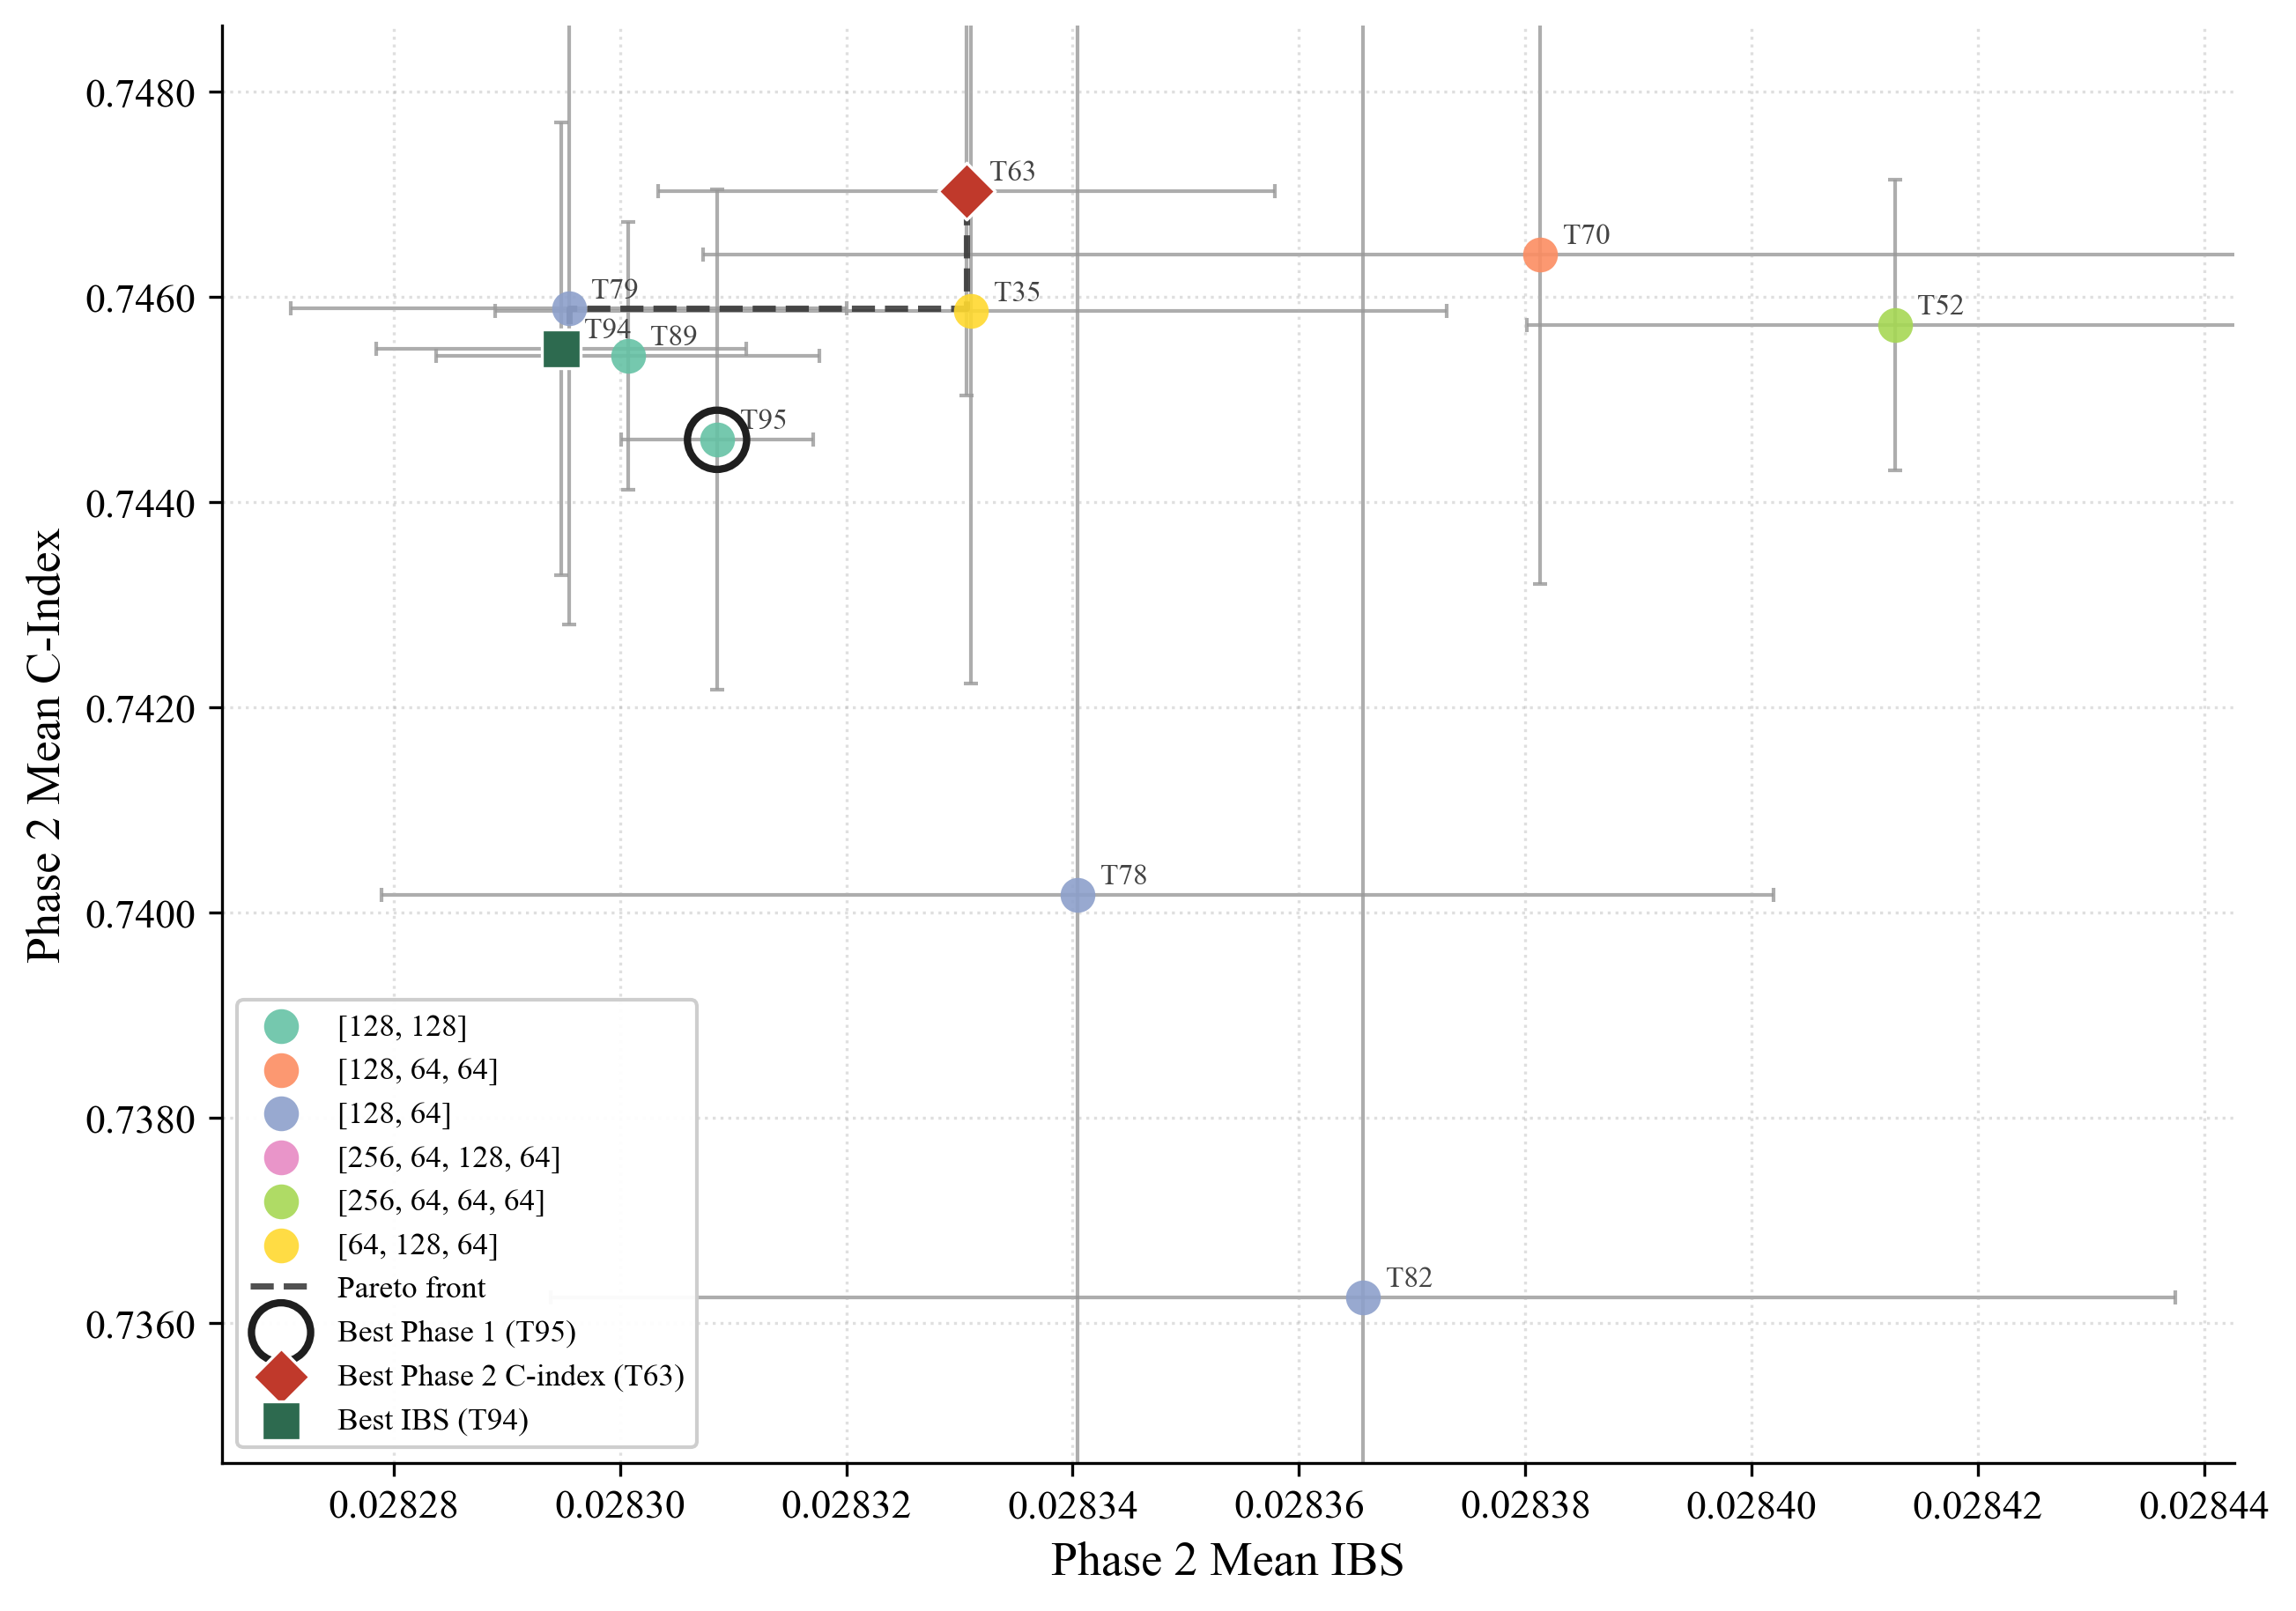

,Phase2_Rank,Trial_Number,Phase1_Rank,Phase2_Mean_CIndex,Phase2_Std_CIndex,Phase2_Mean_IBS,Phase2_Std_IBS,Phase1_Combined_Metric,Architecture,LR,Weight_Decay,Dropout,Batch_Size
0,1,63,4,0.747027,0.001992,0.028331,0.000027,0.253676,"[256, 64, 128, 64]",0.000935,0.000475,0.543012,256
1,2,70,7,0.746412,0.003212,0.028381,0.000074,0.254421,"[128, 64, 64]",0.000628,0.000498,0.581950,256
2,3,79,8,0.745884,0.003080,0.028295,0.000025,0.254464,"[128, 64]",0.000503,0.008241,0.433082,256
3,4,35,2,0.745859,0.003627,0.028331,0.000042,0.253092,"[64, 128, 64]",0.000585,0.000560,0.393491,256
4,5,52,5,0.745729,0.001416,0.028413,0.000033,0.253681,"[256, 64, 64, 64]",0.001563,0.000920,0.583006,256
5,6,94,6,0.745497,0.002206,0.028295,0.000016,0.254230,"[128, 128]",0.000881,0.005664,0.376809,256
6,7,89,3,0.745425,0.001302,0.028301,0.000017,0.253187,"[128, 128]",0.000774,0.006366,0.376655,256
7,8,95,1,0.744607,0.002437,0.028309,0.000008,0.252654,"[128, 128]",0.000930,0.005809,0.327398,256
8,9,78,9,0.740175,0.011617,0.028340,0.000061,0.255014,"[128, 64]",0.000505,0.009161,0.432809,256
9,10,82,10,0.736254,0.012495,0.028366,0.000072,0.255056,"[128, 64]",0.000645,0.009323,0.433394,256


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from datetime import datetime
import re

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False


PROJECT_ROOT = Path.cwd()
FIGS_DIR = PROJECT_ROOT / "_figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

def find_latest_phase2_csv(project_root):
    pattern = re.compile(r"^DS_Phase2_Top10_Validation_(\d{8}_\d{4})\.csv$")
    candidates = []

    for folder in [project_root, project_root / "_out"]:
        if not folder.exists():
            continue

        for path in folder.glob("DS_Phase2_Top10_Validation_*.csv"):
            match = pattern.match(path.name)
            if match:
                stamp = datetime.strptime(match.group(1), "%Y%m%d_%H%M")
                candidates.append((stamp, path))

    if not candidates:
        raise FileNotFoundError("No DS_Phase2_Top10_Validation_YYYYMMDD_HHMM.csv files found.")

    return max(candidates, key=lambda x: x[0])[1]

csv_path = find_latest_phase2_csv(PROJECT_ROOT)
print(f"Using latest CSV: {csv_path}")

df = pd.read_csv(csv_path)

num_cols = [
    "Phase1_Rank", "Trial_Number", "Phase1_Combined_Metric",
    "Phase2_Mean_CIndex", "Phase2_Std_CIndex",
    "Phase2_Mean_IBS", "Phase2_Std_IBS",
    "LR", "Weight_Decay", "Dropout", "Batch_Size", "Phase2_Rank"
]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

required_cols = ["Trial_Number", "Phase2_Mean_IBS", "Phase2_Mean_CIndex"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"CSV is missing required columns: {missing}")

df = df.dropna(subset=required_cols).copy()
df["Trial_Number"] = df["Trial_Number"].astype(int)
df["Batch_Size"] = df["Batch_Size"].astype(int)
df = df.sort_values("Phase2_Rank").reset_index(drop=True)

def compute_pareto_front(df):
    # Minimize Phase2_Mean_IBS, maximize Phase2_Mean_CIndex
    sorted_df = df.sort_values("Phase2_Mean_IBS").reset_index(drop=True)
    pareto = []
    best_c = -np.inf
    for _, row in sorted_df.iterrows():
        if row["Phase2_Mean_CIndex"] >= best_c:
            pareto.append(row)
            best_c = row["Phase2_Mean_CIndex"]
    return pd.DataFrame(pareto)

phase1_winner = df.loc[df["Phase1_Combined_Metric"].idxmin()]
phase2_winner = df.loc[df["Phase2_Mean_CIndex"].idxmax()]
ibs_winner = df.loc[df["Phase2_Mean_IBS"].idxmin()]
pareto_df = compute_pareto_front(df)

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

palette = dict(
    zip(
        sorted(df["Architecture"].dropna().unique()),
        sns.color_palette("Set2", n_colors=df["Architecture"].nunique())
    )
)

fig, ax = plt.subplots(figsize=(8.8, 6.2))

# Error bars
for _, row in df.iterrows():
    ax.errorbar(
        row["Phase2_Mean_IBS"],
        row["Phase2_Mean_CIndex"],
        xerr=row["Phase2_Std_IBS"] if "Phase2_Std_IBS" in df.columns else None,
        yerr=row["Phase2_Std_CIndex"] if "Phase2_Std_CIndex" in df.columns else None,
        fmt="none",
        ecolor="#999999",
        elinewidth=1.0,
        alpha=0.8,
        capsize=2,
        zorder=1
    )

# Scatter by architecture
for arch, sub in df.groupby("Architecture"):
    ax.scatter(
        sub["Phase2_Mean_IBS"], sub["Phase2_Mean_CIndex"],
        s=90, color=palette[arch], alpha=0.9, linewidth=0,
        zorder=3, label=arch
    )

# Pareto front
pf = pareto_df.sort_values("Phase2_Mean_IBS")
ax.step(
    pf["Phase2_Mean_IBS"], pf["Phase2_Mean_CIndex"],
    where="post", color="#333333", alpha=0.85, linewidth=1.7, linestyle="--",
    zorder=2, label="Pareto front"
)

# Highlight Phase 1 winner
ax.scatter(
    phase1_winner["Phase2_Mean_IBS"], phase1_winner["Phase2_Mean_CIndex"],
    facecolors="none", edgecolors="#1f1f1f", s=260, linewidth=2.0, zorder=5,
    label=f"Best Phase 1 (T{int(phase1_winner['Trial_Number'])})"
)

# Highlight Phase 2 winner
ax.scatter(
    phase2_winner["Phase2_Mean_IBS"], phase2_winner["Phase2_Mean_CIndex"],
    marker="D", s=120, color="#c0392b", edgecolor="white", linewidth=0.8, zorder=6,
    label=f"Best Phase 2 C-index (T{int(phase2_winner['Trial_Number'])})"
)

# Optional: highlight IBS winner if different
if int(ibs_winner["Trial_Number"]) != int(phase2_winner["Trial_Number"]):
    ax.scatter(
        ibs_winner["Phase2_Mean_IBS"], ibs_winner["Phase2_Mean_CIndex"],
        marker="s", s=110, color="#2d6a4f", edgecolor="white", linewidth=0.8, zorder=6,
        label=f"Best IBS (T{int(ibs_winner['Trial_Number'])})"
    )

# Labels, offset right/up from points
x_span = df["Phase2_Mean_IBS"].max() - df["Phase2_Mean_IBS"].min()
y_span = df["Phase2_Mean_CIndex"].max() - df["Phase2_Mean_CIndex"].min()
x_offset = max(x_span * 0.0018, 0.000002)
y_offset = max(y_span * 0.0035, 0.00005)

texts = []
for _, row in df.iterrows():
    texts.append(
        ax.text(
            row["Phase2_Mean_IBS"] + x_offset,
            row["Phase2_Mean_CIndex"] + y_offset,
            f"T{int(row['Trial_Number'])}",
            fontsize=8, color="#444444", ha="left", va="bottom"
        )
    )

if HAS_ADJUST_TEXT and texts:
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", color="#bbbbbb", lw=0.5),
        expand=(1.1, 1.2),
        force_text=(0.5, 0.8),
    )

# Axis formatting
x_margin = max((df["Phase2_Mean_IBS"].max() - df["Phase2_Mean_IBS"].min()) * 0.15, 0.00003)
y_margin = max((df["Phase2_Mean_CIndex"].max() - df["Phase2_Mean_CIndex"].min()) * 0.15, 0.001)

ax.set_xlim(df["Phase2_Mean_IBS"].min() - x_margin, df["Phase2_Mean_IBS"].max() + x_margin)
ax.set_ylim(df["Phase2_Mean_CIndex"].min() - y_margin, df["Phase2_Mean_CIndex"].max() + y_margin)

ax.set_xlabel("Phase 2 Mean IBS")
ax.set_ylabel("Phase 2 Mean C-Index")
# ax.set_title("DeepSurv Phase 2 Validation Shortlist", fontsize=14, fontweight="bold", pad=10)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.5f"))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.4f"))

ax.legend(
    fontsize=8.5, loc="lower left",
    frameon=True, facecolor="white", edgecolor="#cccccc", framealpha=0.95
)
ax.grid(True, linestyle=":", alpha=0.4)

sns.despine()
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
fig_path_png = FIGS_DIR / f"deepsurv_phase2_ibs_cindex_{timestamp}.png"
fig_path_pdf = FIGS_DIR / f"deepsurv_phase2_ibs_cindex_{timestamp}.pdf"

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_png}")
print(f"Saved: {fig_path_pdf}")

display(
    df[
        [
            "Phase2_Rank", "Trial_Number", "Phase1_Rank",
            "Phase2_Mean_CIndex", "Phase2_Std_CIndex",
            "Phase2_Mean_IBS", "Phase2_Std_IBS",
            "Phase1_Combined_Metric",
            "Architecture", "LR", "Weight_Decay", "Dropout", "Batch_Size"
        ]
    ].sort_values("Phase2_Rank").reset_index(drop=True)
)


### Targetted grid search

We leveraged Optuna's Bayesian optimization to efficiently find the best hyperparameters for a DeepSurv survival model. By combining stratified 5-fold cross-validation with multi-horizon C-index evaluation, we ensure the model is both highly accurate and generalizable. The code dynamically learns from previous trials to zero in on the optimal learning rate, dropout, and network architecture without wasting time on poor combinations.

1. **Bayesian Efficiency:** Optuna learns from past trials, crushing blind grid search speeds.
2. **Targeted Space:** Search is aggressively narrowed to moderate learning rates (~1e-3) and calibrated dropout (0.28-0.60).
3. **Robust Validation:** Stratified 5-fold CV ensures the model generalizes across patient splits.
4. **Leakage Prevention:** StandardScalers are strictly fit only on the training folds.
5. **Smart Training:** 250 epochs with Early Stopping halts training exactly when optimal.
6. **Weighted Multi-Horizon:** Applies clinical weights (3-6mo: 12.5%, 12-36-60mo: 25% each) to prioritize relevant prognostic windows.
7. **Direct Optimization:** DeepSurv optimizes Cox Partial Likelihood for superior risk ranking.
8. **Memory Safe:** Aggressive garbage collection (`gc.collect`) prevents RAM/GPU out-of-memory crashes.
9. **Architectural Depth:** Tests complex "funnel" networks (e.g., [256, 256, 128]) for interaction mapping.
10. **Graceful Failures:** Optuna safely prunes and ignores folds where `sksurv` tau limits crash.
11. **Reproducible Seeding:** `set_seed(2125)` re-initialized at every trial start eliminates random variance across evaluations.
12. **Checkpoint Safety:** Temporary local directory redirects `.pt` files, preventing WinError 433 crashes on Google Drive File Stream.

In [67]:
#@title ⚡ Step 1.5: DeepSurv Tuning (Targeted Search, Step 1 Combined Metric + Per-Trial Metrics)

import gc
import time
import warnings
import tempfile
import numpy as np
import pandas as pd
import torch
import torchtuples as tt
import random
import os
import optuna
from datetime import datetime
from pycox.models import CoxPH
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sksurv.metrics import concordance_index_ipcw, integrated_brier_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EVAL_HORIZONS = [3, 6, 12, 36, 60]
SEED = 2125

# --- HORIZON WEIGHTS ---
HORIZON_WEIGHTS = {3: 0.125, 6: 0.125, 12: 0.25, 36: 0.25, 60: 0.25}

warnings.filterwarnings("ignore")
log = globals().get("nb_print", print)

# --- Architecture options for targeted search ---
NODE_OPTIONS = {
    "64x128x64": [64, 128, 64],
    "128x128": [128, 128],
    "256x256x128": [256, 256, 128],
    "256x64x64x64": [256, 64, 64, 64],
    "256x64x128x64": [256, 64, 128, 64],
}

def set_seed(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

def prepare_stratified_data(df_idx=0):
    df = imputations_list_mar26[df_idx]
    y_d = y_surv_death_list[df_idx]
    y_r = y_surv_readm_list[df_idx]

    t_d = y_d["time"].values if hasattr(y_d["time"], "values") else y_d["time"]
    e_d_raw = y_d["event"].values if hasattr(y_d["event"], "values") else y_d["event"]
    e_r_raw = y_r["event"].values if hasattr(y_r["event"], "values") else y_r["event"]

    events = np.zeros(len(df), dtype=int)
    times = t_d.copy().astype("float32")
    e_d = e_d_raw.astype(bool)
    e_r = e_r_raw.astype(bool)

    events[e_r] = 2
    events[e_d] = 1

    plan_cols = [
        "plan_type_corr_pg_pr", "plan_type_corr_m_pr",
        "plan_type_corr_pg_pai", "plan_type_corr_m_pai"
    ]
    available_plans = [c for c in plan_cols if c in df.columns]

    plan_category = np.zeros(len(df), dtype=int)
    for i, col in enumerate(available_plans, 1):
        plan_category[df[col] == 1] = i

    strat_labels = (events * 10) + plan_category
    return df, events, times, strat_labels

def to_structured(times, events_bool):
    arr = np.zeros(len(times), dtype=[("e", bool), ("t", float)])
    arr["e"] = events_bool.astype(bool)
    arr["t"] = times.astype(float)
    return arr

def fit_deepsurv(X_train_s, t_train, e_train, X_val_s, t_val, e_val, params, checkpoint_path=None):
    net = tt.practical.MLPVanilla(
        in_features=X_train_s.shape[1],
        num_nodes=params["nodes"],
        out_features=1,
        batch_norm=True,
        dropout=params["dropout"],
        output_bias=False
    )

    model = CoxPH(net, tt.optim.Adam)
    model.set_device(DEVICE)
    model.optimizer.set_lr(params["lr"])
    model.optimizer.param_groups[0]["weight_decay"] = params["weight_decay"]

    callbacks = [
        tt.callbacks.EarlyStopping(
            patience=15,
            file_path=checkpoint_path
        )
    ]

    model.fit(
        X_train_s,
        (t_train.astype("float32"), e_train.astype("int64")),
        batch_size=params["batch_size"],
        epochs=250,
        callbacks=callbacks,
        verbose=False,
        val_data=(X_val_s, (t_val.astype("float32"), e_val.astype("int64")))
    )

    model.compute_baseline_hazards(
        X_train_s,
        (t_train.astype("float32"), e_train.astype("int64"))
    )
    return model

def risk_at_horizon_from_surv_df(surv_df, horizon):
    grid = surv_df.index.values
    idx = np.searchsorted(grid, horizon, side="right") - 1
    idx = int(np.clip(idx, 0, len(grid) - 1))
    return 1.0 - surv_df.iloc[idx].values

def compute_ibs_from_surv_df(surv_df, y_train_struct, y_val_struct, horizons):
    if surv_df is None:
        return np.nan

    grid = surv_df.index.values
    t_min = max(horizons[0], grid[0] + 1e-4)
    t_max = min(horizons[-1], grid[-1] - 1e-4)

    if t_min >= t_max:
        return np.nan

    eval_times = np.array([h for h in horizons if t_min <= h <= t_max])
    if len(eval_times) < 2:
        return np.nan

    surv_matrix = np.zeros((surv_df.shape[1], len(eval_times)))
    for j, h in enumerate(eval_times):
        idx = np.searchsorted(grid, h, side="right") - 1
        idx = int(np.clip(idx, 0, len(grid) - 1))
        surv_matrix[:, j] = surv_df.iloc[idx].values

    try:
        return integrated_brier_score(y_train_struct, y_val_struct, surv_matrix, eval_times)
    except Exception:
        return np.nan

# --- Load Data Once ---
X_all, events_all, times_all, strat_labels = prepare_stratified_data()

def objective(trial):
    set_seed(SEED)

    nodes_key = trial.suggest_categorical("nodes_key", list(NODE_OPTIONS.keys()))
    params = {
        "lr": trial.suggest_float("lr", 5e-4, 1.3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 2e-4, 8e-4, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [256]),
        "dropout": trial.suggest_float("dropout", 0.45, 0.58),
        "nodes": NODE_OPTIONS[nodes_key],
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2125)

    fold_combined_scores = []
    fold_weighted_c_scores = []
    fold_avg_ibs_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, strat_labels)):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

        model_d = None
        model_r = None

        X_train, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
        e_train_raw, e_val_raw = events_all[train_idx], events_all[val_idx]
        t_train, t_val = times_all[train_idx], times_all[val_idx]

        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train).astype("float32")
        X_val_s = scaler.transform(X_val).astype("float32")

        e_train_d = (e_train_raw == 1)
        e_val_d = (e_val_raw == 1)
        e_train_r = (e_train_raw == 2)
        e_val_r = (e_val_raw == 2)

        has_d = (e_train_d.sum() > 0) and (e_val_d.sum() > 0)
        has_r = (e_train_r.sum() > 0) and (e_val_r.sum() > 0)

        if not has_d and not has_r:
            fold_combined_scores.append(np.nan)
            fold_weighted_c_scores.append(np.nan)
            fold_avg_ibs_scores.append(np.nan)
            continue

        with tempfile.TemporaryDirectory() as tmpdir:
            try:
                y_tr_d = y_va_d = None
                y_tr_r = y_va_r = None
                surv_df_d = surv_df_r = None

                if has_d:
                    ckpt_d = os.path.join(tmpdir, f"trial{trial.number}_fold{fold_idx}_death.pt")
                    model_d = fit_deepsurv(
                        X_train_s, t_train, e_train_d,
                        X_val_s, t_val, e_val_d,
                        params, checkpoint_path=ckpt_d
                    )
                    y_tr_d = to_structured(t_train, e_train_d)
                    y_va_d = to_structured(t_val, e_val_d)
                    surv_df_d = model_d.predict_surv_df(X_val_s)

                if has_r:
                    ckpt_r = os.path.join(tmpdir, f"trial{trial.number}_fold{fold_idx}_readm.pt")
                    model_r = fit_deepsurv(
                        X_train_s, t_train, e_train_r,
                        X_val_s, t_val, e_val_r,
                        params, checkpoint_path=ckpt_r
                    )
                    y_tr_r = to_structured(t_train, e_train_r)
                    y_va_r = to_structured(t_val, e_val_r)
                    surv_df_r = model_r.predict_surv_df(X_val_s)

                horizon_cindices = []
                weights_used = []

                for h in EVAL_HORIZONS:
                    c_vals = []

                    if surv_df_d is not None:
                        try:
                            risk_d = risk_at_horizon_from_surv_df(surv_df_d, h)
                            c_d = concordance_index_ipcw(y_tr_d, y_va_d, risk_d, tau=h)[0]
                            if np.isfinite(c_d):
                                c_vals.append(c_d)
                        except Exception:
                            pass

                    if surv_df_r is not None:
                        try:
                            risk_r = risk_at_horizon_from_surv_df(surv_df_r, h)
                            c_r = concordance_index_ipcw(y_tr_r, y_va_r, risk_r, tau=h)[0]
                            if np.isfinite(c_r):
                                c_vals.append(c_r)
                        except Exception:
                            pass

                    if len(c_vals) > 0:
                        horizon_cindices.append(np.mean(c_vals))
                        weights_used.append(HORIZON_WEIGHTS[h])

                if len(horizon_cindices) == 0:
                    fold_combined_scores.append(np.nan)
                    fold_weighted_c_scores.append(np.nan)
                    fold_avg_ibs_scores.append(np.nan)
                    continue

                weighted_c = np.average(horizon_cindices, weights=weights_used)

                ibs_d = compute_ibs_from_surv_df(surv_df_d, y_tr_d, y_va_d, EVAL_HORIZONS) if surv_df_d is not None else np.nan
                ibs_r = compute_ibs_from_surv_df(surv_df_r, y_tr_r, y_va_r, EVAL_HORIZONS) if surv_df_r is not None else np.nan

                ibs_vals = [v for v in [ibs_d, ibs_r] if np.isfinite(v)]
                avg_ibs = np.mean(ibs_vals) if len(ibs_vals) > 0 else np.nan

                if np.isfinite(avg_ibs):
                    combined = np.sqrt((1.0 - weighted_c) ** 2 + avg_ibs ** 2)
                else:
                    combined = 1.0 - weighted_c

                fold_weighted_c_scores.append(weighted_c)
                fold_avg_ibs_scores.append(avg_ibs)
                fold_combined_scores.append(combined)

            except Exception as e:
                print(f"[trial {trial.number} fold {fold_idx}] {type(e).__name__}: {e}")
                fold_weighted_c_scores.append(np.nan)
                fold_avg_ibs_scores.append(np.nan)
                fold_combined_scores.append(np.nan)

            finally:
                if model_d is not None:
                    del model_d
                if model_r is not None:
                    del model_r
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    valid_combined = [x for x in fold_combined_scores if np.isfinite(x)]
    valid_c = [x for x in fold_weighted_c_scores if np.isfinite(x)]
    valid_ibs = [x for x in fold_avg_ibs_scores if np.isfinite(x)]

    if len(valid_combined) == 0:
        raise optuna.exceptions.TrialPruned(f"Trial {trial.number} produced no valid fold scores")

    mean_combined = float(np.mean(valid_combined))
    mean_weighted_c = float(np.mean(valid_c)) if len(valid_c) > 0 else np.nan
    mean_avg_ibs = float(np.mean(valid_ibs)) if len(valid_ibs) > 0 else np.nan

    trial.set_user_attr("combined_metric", mean_combined)
    trial.set_user_attr("weighted_uno_c", mean_weighted_c)
    trial.set_user_attr("avg_ibs", mean_avg_ibs)
    trial.set_user_attr("n_valid_folds", len(valid_combined))

    log(
        f"Trial {trial.number:>3d} | "
        f"combined={mean_combined:.4f} | "
        f"UnoC={mean_weighted_c:.4f} | "
        f"IBS={mean_avg_ibs:.4f} | "
        f"nodes={params['nodes']} | "
        f"lr={params['lr']:.2e} | "
        f"wd={params['weight_decay']:.2e} | "
        f"do={params['dropout']:.3f} | "
        f"bs={params['batch_size']}"
    )

    return mean_combined


In [ ]:
# --- RUN OPTUNA ---
start_time = time.time()
log("Starting DeepSurv Tuning with Bayesian Optimization (Optuna, Step 1 combined metric)...")

study_targetted = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name="deepsurv_cs_tuning_bayesian_targetted_combined"
)

study_targetted.optimize(objective, n_trials=50, show_progress_bar=True)

log("\n" + "=" * 60)

complete_trials = [t for t in study_targetted.trials if t.state == optuna.trial.TrialState.COMPLETE]

if len(complete_trials) == 0:
    log("No completed trials. Check printed fold errors above.")
else:
    best_trial = study_targetted.best_trial
    best_params = dict(best_trial.params)
    best_params["nodes"] = NODE_OPTIONS[best_params["nodes_key"]]

    log(f"Best DeepSurv Config Found: {best_params}")
    log(f"Best Combined Metric: {study_targetted.best_value:.4f} (lower is better)")
    log(f"Best Weighted Uno's C-index: {best_trial.user_attrs.get('weighted_uno_c', np.nan):.4f}")
    log(f"Best Average IBS: {best_trial.user_attrs.get('avg_ibs', np.nan):.4f}")

log("=" * 60)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
results_df2 = study_targetted.trials_dataframe(
    attrs=("number", "value", "datetime_start", "datetime_complete", "duration", "params", "user_attrs", "state")
)

# Flatten MultiIndex columns for easier CSV reading
results_df2.columns = [
    "_".join([str(x) for x in col if str(x) != ""]) if isinstance(col, tuple) else str(col)
    for col in results_df2.columns
]


[I 2026-04-01 13:30:14,968] A new study created in memory with name: deepsurv_cs_tuning_bayesian_targetted_combined
  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.257279:   2%|▏         | 1/50 [04:35<3:44:50, 275.31s/it]

Best trial: 1. Best value: 0.254475:   4%|▍         | 2/50 [08:28<3:20:24, 250.51s/it]

Best trial: 2. Best value: 0.254175:   6%|▌         | 3/50 [13:00<3:23:48, 260.17s/it]

Best trial: 3. Best value: 0.250351:   8%|▊         | 4/50 [17:11<3:16:47, 256.68s/it]

...

Best trial: 36. Best value: 0.249822:  94%|█████████▍| 47/50 [3:50:22<13:35, 271.97s/it]

Best trial: 36. Best value: 0.249822:  96%|█████████▌| 48/50 [3:54:08<08:36, 258.03s/it]

Best trial: 36. Best value: 0.249822:  98%|█████████▊| 49/50 [3:58:38<04:21, 261.72s/it]

Best trial: 36. Best value: 0.249822: 100%|██████████| 50/50 [4:03:14<00:00, 291.90s/it]


OSError: [Errno 22] Invalid argument: 'DS_Optuna_Tuning_TargetedCombined_20260401_1733.csv'

In [69]:

PROJECT_ROOT = Path(r"g:\My Drive\Alvacast\SISTRAT 2023\dh")
OUT_DIR = PROJECT_ROOT / "_out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# optional: reset cwd explicitly
os.chdir(PROJECT_ROOT)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
filename2 = OUT_DIR / f"DS_Optuna_Tuning_TargetedCombined_{timestamp}.csv"
results_df2.to_csv(filename2, index=False)

log(f"Full trials history saved to: {filename2}")
log(f"Total Time: {(time.time() - start_time) / 60:.2f} min")

Total Time: 247.25 min

In [70]:
#@title 📝 Take-Home Message: Interpretation of Targeted Optuna Results

import pandas as pd
from IPython.display import display

# --- UPDATED HYPERPARAMETER INTERPRETATION DATAFRAME ---
config_interpretation = pd.DataFrame([
    {
        'Component': 'Regularization (Balanced Shield)',
        'Selected Value': 'Dropout: 0.514 | Weight Decay: 0.000703',
        'Interpretation': 'The updated targeted search winner favors moderate-high dropout together with modest L2 regularization. This combination suggests the model benefits from strong stochastic regularization to suppress noisy co-adaptations, while still using enough weight decay to stabilize the Cox risk surface without over-shrinking it.'
    },
    {
        'Component': 'Model Capacity (Lean Twin Architecture)',
        'Selected Value': 'Nodes: [128, 128]',
        'Interpretation': 'The new best targeted-search model is a compact 2-layer architecture rather than a wider funnel. This indicates that, under the narrowed search space and combined-metric objective, a leaner network was sufficient to capture the relevant nonlinear survival structure. In other words, extra depth did not translate into better discrimination-calibration trade-off in this run.'
    },
    {
        'Component': 'Optimization Mechanics',
        'Selected Value': 'Batch: 256 | LR: 0.000983',
        'Interpretation': 'The optimizer again selected batch size 256, reinforcing the earlier pattern that smaller batches are more effective for this DeepSurv setup. The learning rate remained close to 1e-3, which appears to be the stable operating region for navigating the Cox partial likelihood landscape efficiently without becoming erratic.'
    },
    {
        'Component': 'Performance Context (Best Targeted Combined-Metric Result)',
        'Selected Value': 'Combined Metric: 0.2498 | Weighted Uno C-Index: 0.7518 | Average IBS: 0.0283',
        'Interpretation': 'This configuration delivered the best result in the targeted Optuna search under the Step 1 combined metric. The improvement over earlier targeted candidates is modest, and IBS changed very little across top trials, so the gain appears to come mainly from slightly better discrimination rather than a major shift in calibration.'
    }
])

# --- DISPLAY ---
nb_print("\n>>> TAKE-HOME MESSAGE: DEEPSURV TARGETED OPTUNA OPTIMIZATION (BEST COMBINED METRIC = 0.2498)")
pd.set_option('display.max_colwidth', None)

styled_table = (
    config_interpretation.style
    .set_properties(**{
        "text-align": "left",
        "white-space": "pre-wrap",
        "font-size": "14px",
        "vertical-align": "top"
    })
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f0f2f6"), ("font-weight", "bold"), ("font-size", "14px")]},
        {"selector": "td", "props": [("padding", "12px"), ("border-bottom", "1px solid #ddd")]}
    ])
)

display(styled_table)


,Component,Selected Value,Interpretation
0,Regularization (Balanced Shield),Dropout: 0.514 | Weight Decay: 0.000703,"The updated targeted search winner favors moderate-high dropout together with modest L2 regularization. This combination suggests the model benefits from strong stochastic regularization to suppress noisy co-adaptations, while still using enough weight decay to stabilize the Cox risk surface without over-shrinking it."
1,Model Capacity (Lean Twin Architecture),"Nodes: [128, 128]","The new best targeted-search model is a compact 2-layer architecture rather than a wider funnel. This indicates that, under the narrowed search space and combined-metric objective, a leaner network was sufficient to capture the relevant nonlinear survival structure. In other words, extra depth did not translate into better discrimination-calibration trade-off in this run."
2,Optimization Mechanics,Batch: 256 | LR: 0.000983,"The optimizer again selected batch size 256, reinforcing the earlier pattern that smaller batches are more effective for this DeepSurv setup. The learning rate remained close to 1e-3, which appears to be the stable operating region for navigating the Cox partial likelihood landscape efficiently without becoming erratic."
3,Performance Context (Best Targeted Combined-Metric Result),Combined Metric: 0.2498 | Weighted Uno C-Index: 0.7518 | Average IBS: 0.0283,"This configuration delivered the best result in the targeted Optuna search under the Step 1 combined metric. The improvement over earlier targeted candidates is modest, and IBS changed very little across top trials, so the gain appears to come mainly from slightly better discrimination rather than a major shift in calibration."


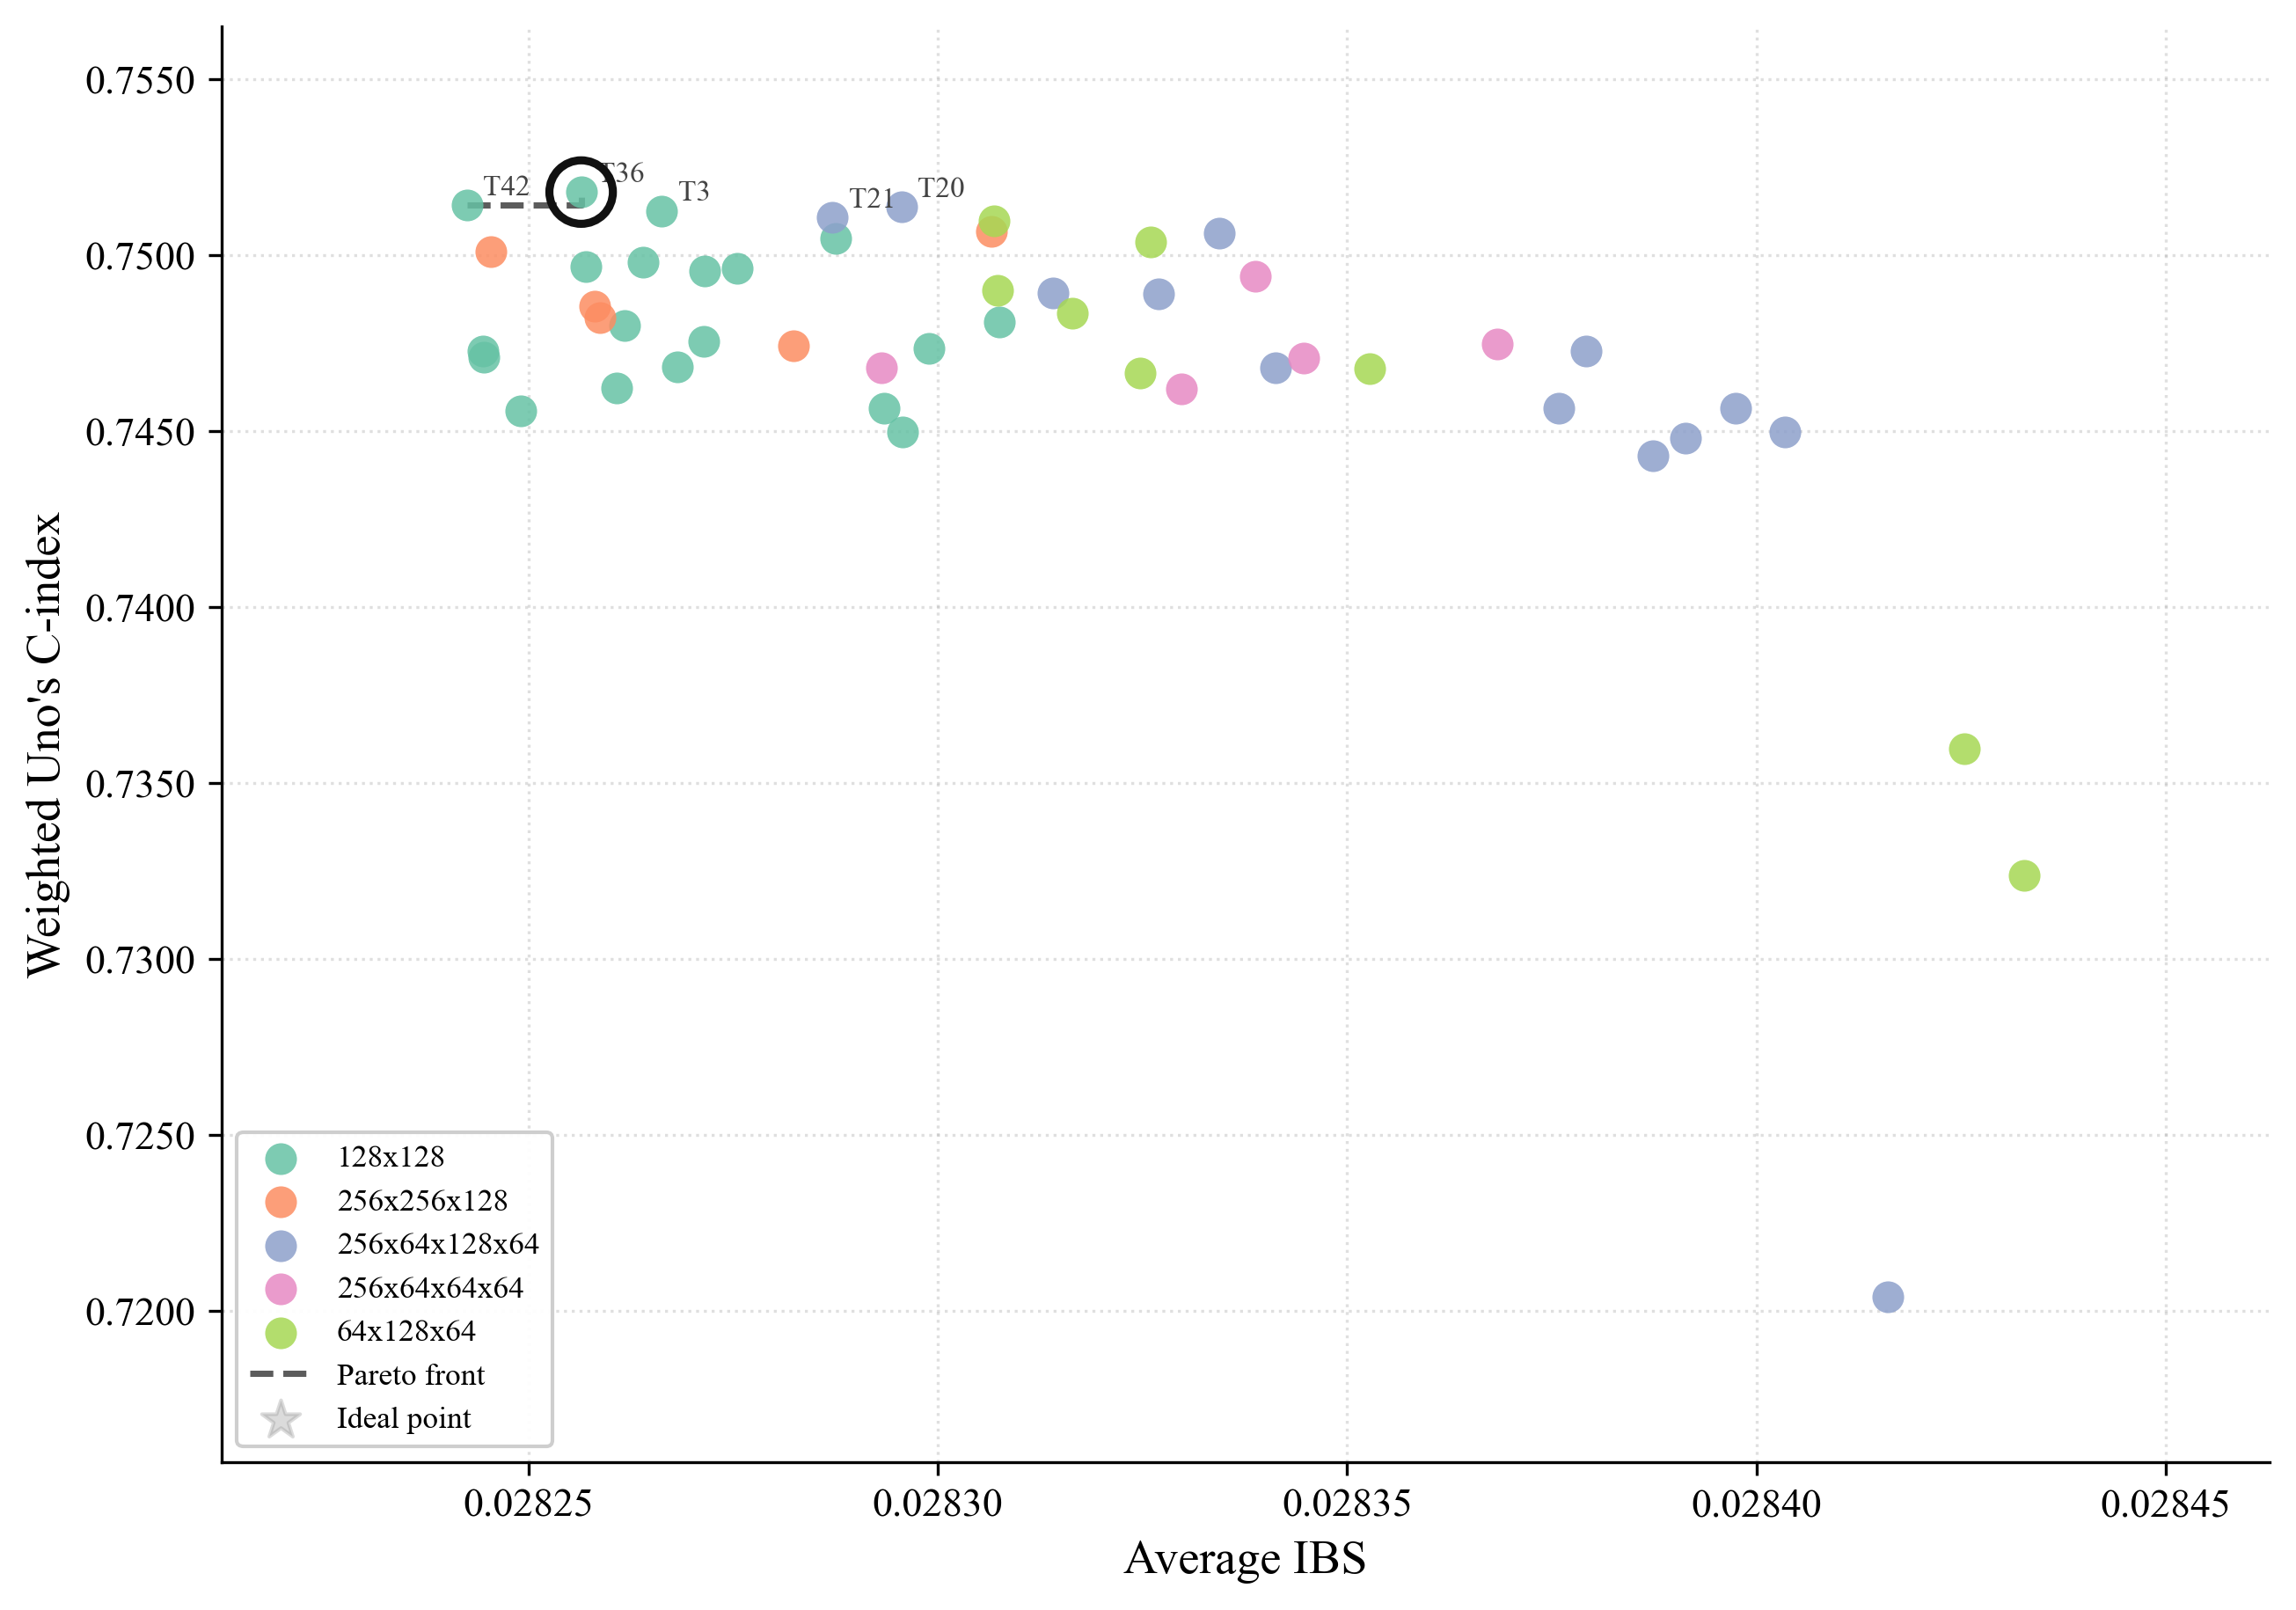

,trial_id,Architecture,Combined,UnoC,IBS,LR,Weight_Decay,Dropout,Batch_Size
0,36,128x128,0.249822,0.751791,0.028256,0.000983,0.000703,0.513985,256
1,42,128x128,0.250185,0.751426,0.028242,0.000995,0.000626,0.513084,256
2,20,256x64x128x64,0.250250,0.751365,0.028296,0.001114,0.000492,0.470506,256
3,3,128x128,0.250351,0.751260,0.028266,0.001071,0.000578,0.530863,256
4,21,256x64x128x64,0.250539,0.751069,0.028287,0.001116,0.000502,0.466758,256
5,10,64x128x64,0.250650,0.750963,0.028307,0.000939,0.000781,0.457133,256
6,18,256x256x128,0.250941,0.750670,0.028307,0.001262,0.000676,0.505571,256
7,14,256x64x128x64,0.250995,0.750621,0.028334,0.000824,0.000465,0.577049,256
8,40,128x128,0.251132,0.750474,0.028288,0.001074,0.000282,0.531766,256
9,31,64x128x64,0.251241,0.750370,0.028326,0.000917,0.000632,0.457582,256


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from datetime import datetime
import re

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False


PROJECT_ROOT = Path.cwd()
FIGS_DIR = PROJECT_ROOT / "_figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

def find_latest_deepsurv_csv(project_root):
    patterns = [
        re.compile(r"^DS_Optuna_Tuning_TargetedCombined_(\d{8}_\d{4})\.csv$"),
    ]
    candidates = []

    for folder in [project_root, project_root / "_out"]:
        if not folder.exists():
            continue

        for path in folder.glob("DS_Optuna_Tuning*.csv"):
            for pattern in patterns:
                match = pattern.match(path.name)
                if match:
                    stamp = datetime.strptime(match.group(1), "%Y%m%d_%H%M")
                    candidates.append((stamp, path))
                    break

    if not candidates:
        raise FileNotFoundError("No matching DeepSurv Optuna CSV files found.")

    return max(candidates, key=lambda x: x[0])[1]


csv_path = find_latest_deepsurv_csv(PROJECT_ROOT)
print(f"Using latest CSV: {csv_path}")
df = pd.read_csv(csv_path)

df = df[df["state"] == "COMPLETE"].copy()

rename_map = {
    "number": "trial_id",
    "user_attrs_avg_ibs": "IBS",
    "user_attrs_weighted_uno_c": "UnoC",
    "user_attrs_combined_metric": "Combined",
    "params_nodes_key": "Architecture",
    "params_batch_size": "Batch_Size",
    "params_dropout": "Dropout",
    "params_lr": "LR",
    "params_weight_decay": "Weight_Decay",
}
df = df.rename(columns=rename_map)

num_cols = ["trial_id", "IBS", "UnoC", "Combined", "Batch_Size", "Dropout", "LR", "Weight_Decay"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["trial_id", "IBS", "UnoC", "Combined"]).copy()
df["trial_id"] = df["trial_id"].astype(int)
df = df.sort_values("trial_id").reset_index(drop=True)

def get_best_trial_row(df):
    return df.loc[df["Combined"].idxmin()]

def compute_pareto_front(df):
    sorted_df = df.sort_values("IBS").reset_index(drop=True)
    pareto = []
    best_c = -np.inf
    for _, row in sorted_df.iterrows():
        if row["UnoC"] >= best_c:
            pareto.append(row)
            best_c = row["UnoC"]
    return pd.DataFrame(pareto)

winner = get_best_trial_row(df)
pareto_df = compute_pareto_front(df)
top5_df = df.nsmallest(5, "Combined").copy()

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

palette = dict(
    zip(
        sorted(df["Architecture"].dropna().unique()),
        sns.color_palette("Set2", n_colors=df["Architecture"].nunique())
    )
)

fig, ax = plt.subplots(figsize=(8.8, 6.2))

for arch, sub in df.groupby("Architecture"):
    ax.scatter(
        sub["IBS"], sub["UnoC"],
        s=75, color=palette[arch], alpha=0.85, linewidth=0, zorder=3,
        label=arch
    )

pf = pareto_df.sort_values("IBS")
ax.step(
    pf["IBS"], pf["UnoC"],
    where="post", color="#333333", alpha=0.8, linewidth=1.7, linestyle="--",
    zorder=2, label="Pareto front"
)

# Highlight winner without adding it to legend
ax.scatter(
    winner["IBS"], winner["UnoC"],
    facecolors="none", edgecolors="#111111", s=300, linewidth=2.2, zorder=5
)

ax.scatter(
    0, 1, marker="*", s=120, color="#999999", alpha=0.35, zorder=1,
    label="Ideal point"
)

label_ids = set(pareto_df["trial_id"].tolist()) | set(top5_df["trial_id"].tolist())

x_span = df["IBS"].max() - df["IBS"].min()
y_span = df["UnoC"].max() - df["UnoC"].min()
x_offset = max(x_span * 0.0018, 0.000002)
y_offset = max(y_span * 0.0035, 0.00005)

texts = []
for _, row in df[df["trial_id"].isin(label_ids)].iterrows():
    texts.append(
        ax.text(
            row["IBS"] + x_offset,
            row["UnoC"] + y_offset,
            f"T{int(row['trial_id'])}",
            fontsize=8, color="#444444", ha="left", va="bottom"
        )
    )

if HAS_ADJUST_TEXT and texts:
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", color="#bbbbbb", lw=0.5),
        expand=(1.05, 1.08),
        force_text=(0.25, 0.35),
    )

x_margin = max((df["IBS"].max() - df["IBS"].min()) * 0.15, 0.00003)
y_margin = max((df["UnoC"].max() - df["UnoC"].min()) * 0.15, 0.001)

ax.set_xlim(df["IBS"].min() - x_margin, df["IBS"].max() + x_margin)
ax.set_ylim(df["UnoC"].min() - y_margin, df["UnoC"].max() + y_margin)

ax.set_xlabel("Average IBS")
ax.set_ylabel("Weighted Uno's C-index")
# ax.set_title("DeepSurv Targeted Optuna: Pareto Front", fontsize=14, fontweight="bold", pad=10)

ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.5f"))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.4f"))

ax.legend(
    fontsize=8.5, loc="lower left",
    frameon=True, facecolor="white", edgecolor="#cccccc", framealpha=0.95
)
ax.grid(True, linestyle=":", alpha=0.4)

sns.despine()
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
fig_path_png = FIGS_DIR / f"deepsurv_targeted_pareto_{timestamp}.png"
fig_path_pdf = FIGS_DIR / f"deepsurv_targeted_pareto_{timestamp}.pdf"

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_png}")
print(f"Saved: {fig_path_pdf}")

display(
    df.nsmallest(10, "Combined")[
        ["trial_id", "Architecture", "Combined", "UnoC", "IBS", "LR", "Weight_Decay", "Dropout", "Batch_Size"]
    ].reset_index(drop=True)
)
